# Task 1: Exploratory Analysis and Variable Admissibility

In [493]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

train = pd.read_csv('train_group.csv')
train['dteday'] = pd.to_datetime(train['dteday'])

print(train.shape)
train.head(3)

(585, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,292,2011-10-19,4,0,10,0,3,1,3,0.541739,0.513848,0.895217,0.243339,254,2170,2424
1,136,2011-05-16,2,0,5,0,1,1,1,0.577500,0.550512,0.787917,0.126871,773,3185,3958
2,79,2011-03-20,1,0,3,0,0,0,1,0.332500,0.325750,0.473750,0.207721,1047,1424,2471


## 1.1 Variable Admissibility

Before any modelling, we classify each variable by whether it can legitimately serve as a predictor.
The key question for the **prediction setting** is whether the variable is known at forecast time (before any
user counts for that day are observed).

| Variable | Role | Admissibility | Reason |
|---|---|---|---|
| `cnt` | Response |  | Target variable |
| `casual` | Predictor candidate | **Inadmissible** | Component of `cnt`; not observed before day ends |
| `registered` | Predictor candidate | **Inadmissible** | Component of `cnt`; not observed before day ends |
| `instant` | Row index | **Inadmissible** | Arbitrary identifier with no substantive meaning |
| `dteday` | Date | **Inadmissible (raw)** | Encodes the same information as `yr` + `mnth`; using a raw date would cause data leakage on future dates |
| `temp` | Weather | **Clearly admissible** | Daily forecast available before the day |
| `atemp` | Weather | **Admissible with caveat** | Near-duplicate of `temp` (r > 0.99); including both risks collinearity |
| `hum` | Weather | **Clearly admissible** | Daily forecast available |
| `windspeed` | Weather | **Clearly admissible** | Daily forecast available |
| `weathersit` | Weather | **Clearly admissible** | Daily forecast categorical available |
| `season` | Calendar | **Clearly admissible** | Known at scheduling time |
| `yr` | Calendar | **Admissible with caveat** | Captures a linear trend over two years; limited generalisability beyond 2012 |
| `mnth` | Calendar | **Admissible with caveat** | Overlaps heavily with `season`; one of the two is usually sufficient |
| `holiday` | Calendar | **Clearly admissible** | Published in advance |
| `weekday` | Calendar | **Clearly admissible** | Known at scheduling time |
| `workingday` | Calendar | **Admissible with caveat** | Derived from `weekday` and `holiday`; may be redundant if both are included |

**On `casual` and `registered`:** These two variables are not merely correlated with `cnt` -- they sum to it
exactly (`casual + registered = cnt`). Including either as a predictor would be a form of data leakage:
rider counts are not known until after the rental period closes, which is the very quantity we are trying to
predict. They are also mechanically linked to the response rather than causally upstream of it.
Both are inadmissible in any prediction model. For explanatory modelling they could in principle be used
as a decomposition tool, but not as predictors of `cnt`.

**On `dteday`:** The raw date string carries no additional information beyond what `yr`, `mnth`, and `weekday`
already encode. It will not be used as a predictor.

In [494]:
# Verify: casual + registered = cnt exactly
assert (train['casual'] + train['registered'] == train['cnt']).all(), 'Identity does not hold'
print('casual + registered = cnt holds for all', len(train), 'training rows')

casual + registered = cnt holds for all 585 training rows


## 1.2 Response Variable: Distribution of **cnt**

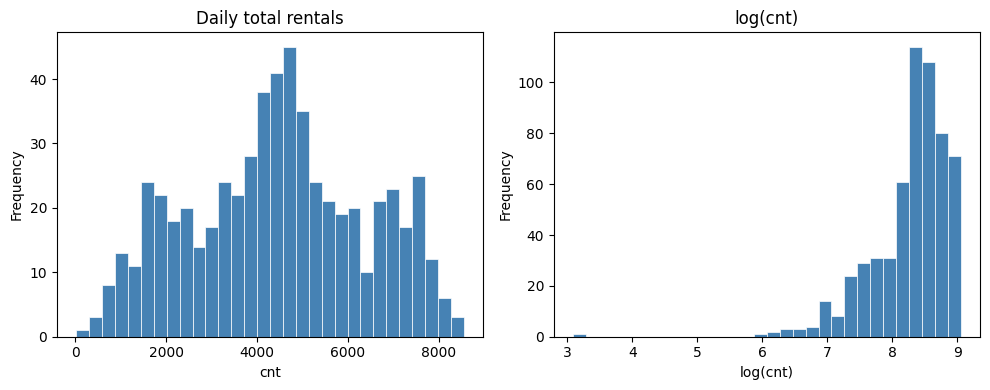

count     585.0
mean     4457.2
std      1936.4
min        22.0
25%      3115.0
50%      4507.0
75%      5847.0
max      8555.0
Name: cnt, dtype: float64
Skewness (cnt):      -0.036
Skewness (log cnt):  -2.049


In [495]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(train['cnt'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('cnt')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Daily total rentals')

axes[1].hist(np.log(train['cnt']), bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('log(cnt)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('log(cnt)')

plt.tight_layout()
plt.savefig('task1/fig_cnt_distribution.pdf', dpi=150, bbox_inches='tight')
plt.show()

print(train['cnt'].describe().round(1))
print(f'Skewness (cnt):      {train["cnt"].skew():.3f}')
print(f'Skewness (log cnt):  {np.log(train["cnt"]).skew():.3f}')

`cnt` is approximately bell-shaped with a mild right skew. The distribution is reasonably well-behaved for regression without transformation. `log(cnt)` introduces a left skew and does not improve symmetry here. We will evaluate whether a log transformation is justified more carefully in Task 2, but the raw distribution alone does not strongly motivate it.

## 1.3 Temporal and Calendar Patterns

These plots motivate which calendar variables carry signal and whether there is a year-on-year trend.

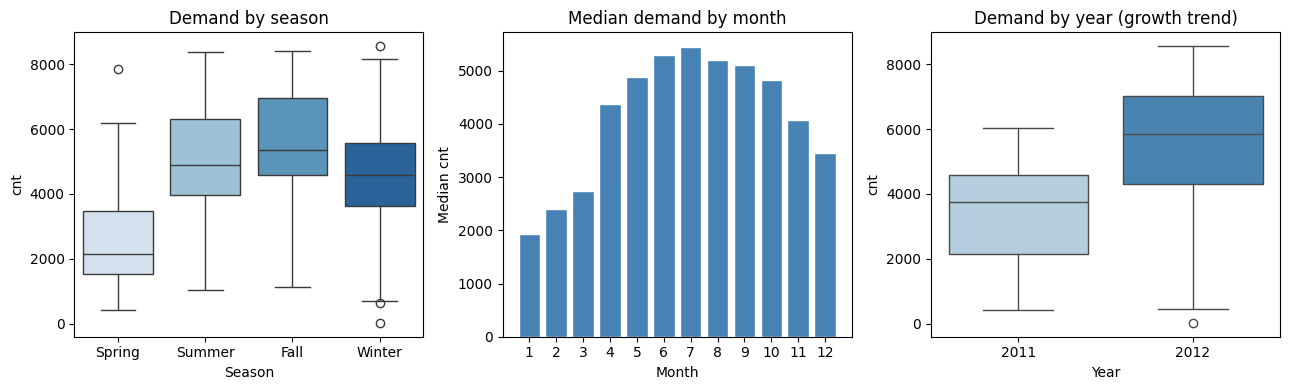

In [496]:
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
train['season_label'] = train['season'].map(season_labels)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Season
order = ['Spring', 'Summer', 'Fall', 'Winter']
sns.boxplot(data=train, x='season_label', y='cnt', order=order, palette='Blues', ax=axes[0])
axes[0].set_xlabel('Season')
axes[0].set_ylabel('cnt')
axes[0].set_title('Demand by season')

# Month
monthly = train.groupby('mnth')['cnt'].median()
axes[1].bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Median cnt')
axes[1].set_title('Median demand by month')
axes[1].set_xticks(range(1, 13))

# Year
sns.boxplot(data=train, x='yr', y='cnt', palette='Blues', ax=axes[2])
axes[2].set_xticklabels(['2011', '2012'])
axes[2].set_xlabel('Year')
axes[2].set_ylabel('cnt')
axes[2].set_title('Demand by year (growth trend)')

plt.tight_layout()
plt.savefig('task1/fig_temporal_patterns.pdf', dpi=150, bbox_inches='tight')
plt.show()

Demand peaks in summer/fall and troughs in spring and winter, consistent with weather-driven leisure riding.
The month plot refines this: demand builds from March, peaks around June-September, then declines.
There is a clear year-on-year growth from 2011 to 2012, suggesting `yr` captures a business-growth trend
that should be included in models. Because `season` and `mnth` are highly redundant, we will generally
prefer `mnth` for finer granularity, or `season` for parsimony, but not both simultaneously.

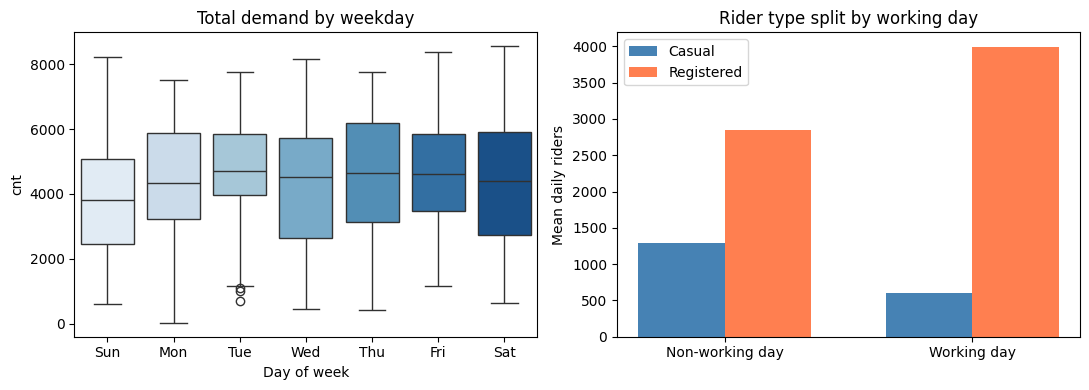

In [497]:
weekday_labels = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
train['weekday_label'] = train['weekday'].map(weekday_labels)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order_wd = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
sns.boxplot(data=train, x='weekday_label', y='cnt', order=order_wd, palette='Blues', ax=axes[0])
axes[0].set_xlabel('Day of week')
axes[0].set_ylabel('cnt')
axes[0].set_title('Total demand by weekday')

# Casual vs registered split by workingday
comp = train.groupby('workingday')[['casual', 'registered']].mean().reset_index()
x = np.arange(2)
width = 0.35
axes[1].bar(x - width/2, comp['casual'], width, label='Casual', color='steelblue')
axes[1].bar(x + width/2, comp['registered'], width, label='Registered', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Non-working day', 'Working day'])
axes[1].set_ylabel('Mean daily riders')
axes[1].set_title('Rider type split by working day')
axes[1].legend()

plt.tight_layout()
plt.savefig('task1/fig_weekday_patterns.pdf', dpi=150, bbox_inches='tight')
plt.show()

Total demand is fairly stable across weekdays, but the composition differs sharply: on working days,
registered riders dominate (commuters), while on weekends casual riders make up a larger share.
This pattern motivates the strategic question: the system serves two structurally different demand types.
Even though `casual` and `registered` are inadmissible as predictors, this decomposition informs which
calendar features (workingday, weekday) are important for modelling total demand and understanding its drivers.

## 1.4 Weather Variable Relationships

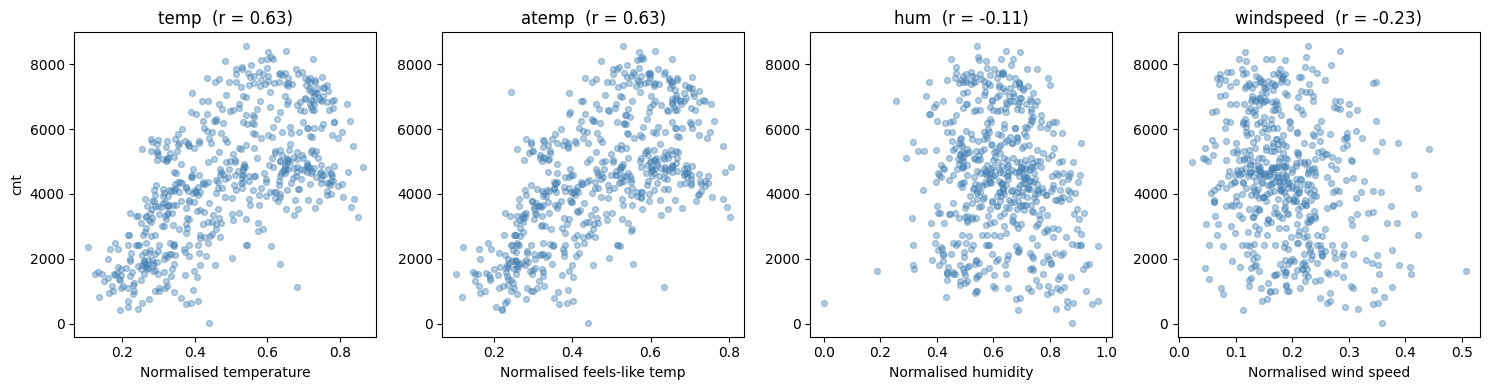

In [498]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

weather_vars = ['temp', 'atemp', 'hum', 'windspeed']
labels = ['Normalised temperature', 'Normalised feels-like temp', 'Normalised humidity', 'Normalised wind speed']

for ax, var, lab in zip(axes, weather_vars, labels):
    ax.scatter(train[var], train['cnt'], alpha=0.4, s=18, color='steelblue')
    ax.set_xlabel(lab)
    ax.set_ylabel('cnt' if ax == axes[0] else '')
    r = train[var].corr(train['cnt'])
    ax.set_title(f'{var}  (r = {r:.2f})')

plt.tight_layout()
plt.savefig('task1/fig_weather_scatter.pdf', dpi=150, bbox_inches='tight')
plt.show()

`temp` and `atemp` show a strong positive association with `cnt` and are nearly identical (see correlation below).
Using both in the same model will cause severe multicollinearity; `temp` is preferred as it is the physically
interpretable measure. Humidity shows a mild negative association. Wind speed has a weak negative association
with noticeable scatter. Neither humidity nor wind speed alone explains much variance, but they may contribute
alongside temperature in a joint model.

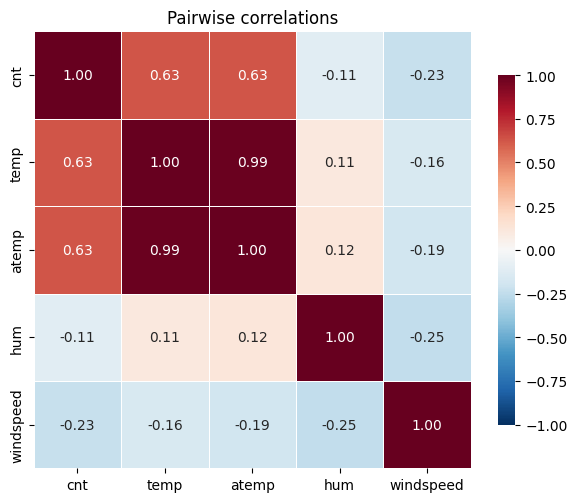

temp vs atemp correlation: 0.9905


In [499]:
# Correlation among admissible continuous predictors and response
cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed']
corr = train[cols].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Pairwise correlations')
plt.tight_layout()
plt.savefig('task1/fig_correlation_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()

print('temp vs atemp correlation:', train['temp'].corr(train['atemp']).round(4))

## 1.5 Categorical Weather: `weathersit`

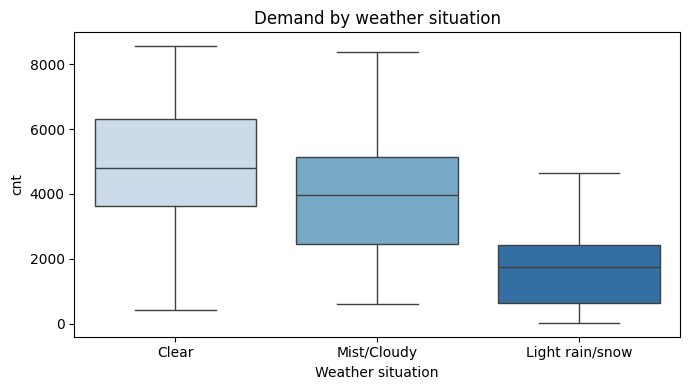

                 median  count
ws_label                      
Clear            4788.5    374
Mist/Cloudy      3959.0    195
Light rain/snow  1751.0     16


In [500]:
ws_labels = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light rain/snow', 4: 'Heavy rain/snow'}
train['ws_label'] = train['weathersit'].map(ws_labels)

ws_order = ['Clear', 'Mist/Cloudy', 'Light rain/snow', 'Heavy rain/snow']
ws_order_present = [w for w in ws_order if w in train['ws_label'].unique()]

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train, x='ws_label', y='cnt', order=ws_order_present, palette='Blues', ax=ax)
ax.set_xlabel('Weather situation')
ax.set_ylabel('cnt')
ax.set_title('Demand by weather situation')
plt.tight_layout()
plt.savefig('task1/fig_weathersit.pdf', dpi=150, bbox_inches='tight')
plt.show()

print(train.groupby('ws_label')['cnt'].agg(['median', 'count']).loc[ws_order_present])

Demand drops monotonically as weather worsens. Clear days have roughly twice the median demand of
light rain/snow days. Category 4 (heavy rain/snow) has very few observations in training data and may
need to be merged with category 3 to avoid unstable coefficient estimates.

## 1.6 Summary: Key Findings for Modelling

The exploratory analysis points to the following:

1. **`casual` and `registered` are inadmissible** as predictors in any model for `cnt`. They are sub-components
   of the response, observed simultaneously with it, and including them is equivalent to predicting the whole
   from its own parts. Their pattern across working days is informative about demand structure but not usable
   as a predictor.

2. **`temp` is the strongest single predictor** (r = 0.63 with cnt). `atemp` is redundant given `temp`
   (r > 0.99 between the two); only one should enter any model.

3. **Seasonal and monthly patterns are strong** and partially mediated by temperature. `season` and `mnth`
   are collinear; for most purposes one suffices. `yr` captures a real growth trend and should be retained.

4. **Working day structure matters** for understanding demand composition, and `workingday` (or `weekday`)
   should be included in explanatory and predictive models.

5. **`log(cnt)` is worth considering** given mild right-skew, and will be evaluated formally in Task 2.

6. The relationship between `temp` and `cnt` is likely confounded by season: warmer temperatures coincide
   with summer, which also brings longer daylight hours and more discretionary time. A simple regression
   of `cnt` on `temp` alone will overstate the causal role of temperature.

# Task 2: Simple Relationship between Temperature and Total Demand

In [501]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

train = pd.read_csv('train_group.csv')
train['dteday'] = pd.to_datetime(train['dteday'])
train['log_cnt'] = np.log(train['cnt'])
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
train['season_label'] = train['season'].map(season_labels)

print(f'Training rows: {len(train)}')
train[['temp', 'cnt', 'log_cnt']].describe().round(3)

Training rows: 585


,temp,cnt,log_cnt
count,585.000,585.000,585.000
mean,0.491,4457.161,8.269
std,0.182,1936.379,0.598
min,0.108,22.000,3.091
25%,0.330,3115.000,8.044
50%,0.484,4507.000,8.413
75%,0.651,5847.000,8.674
max,0.862,8555.000,9.054


## 2.1 Exploratory Plot: Temperature vs Total Demand

We begin with a scatter plot of **temp** against **cnt**, overlaid with a LOWESS smoother to reveal the
empirical shape of the relationship before imposing any parametric form. Points are coloured by season
to flag potential confounding.

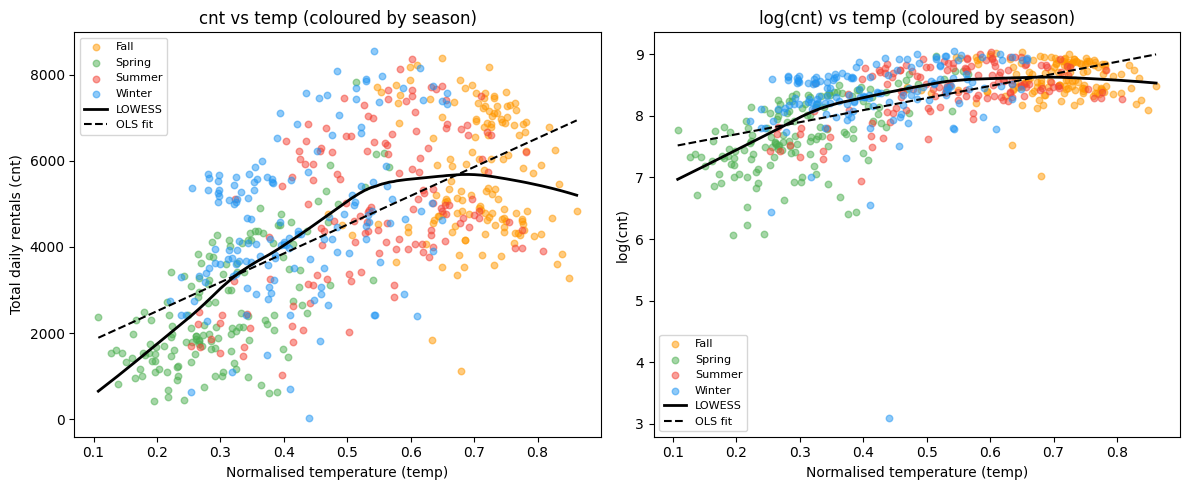

In [502]:
palette = {'Spring': '#4CAF50', 'Summer': '#F44336', 'Fall': '#FF9800', 'Winter': '#2196F3'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for season, grp in train.groupby('season_label'):
    axes[0].scatter(grp['temp'], grp['cnt'], alpha=0.5, s=22, color=palette[season], label=season)

lowess = sm.nonparametric.lowess(train['cnt'], train['temp'], frac=0.4)
axes[0].plot(lowess[:, 0], lowess[:, 1], color='black', linewidth=2, label='LOWESS')

m_simple = smf.ols('cnt ~ temp', data=train).fit()
x_line = np.linspace(train['temp'].min(), train['temp'].max(), 200)
y_line = m_simple.params['Intercept'] + m_simple.params['temp'] * x_line
axes[0].plot(x_line, y_line, 'k--', linewidth=1.5, label='OLS fit')
axes[0].set_xlabel('Normalised temperature (temp)')
axes[0].set_ylabel('Total daily rentals (cnt)')
axes[0].set_title('cnt vs temp (coloured by season)')
axes[0].legend(fontsize=8)

m_log = smf.ols('log_cnt ~ temp', data=train).fit()
for season, grp in train.groupby('season_label'):
    axes[1].scatter(grp['temp'], grp['log_cnt'], alpha=0.5, s=22, color=palette[season], label=season)

lowess_log = sm.nonparametric.lowess(train['log_cnt'], train['temp'], frac=0.4)
axes[1].plot(lowess_log[:, 0], lowess_log[:, 1], color='black', linewidth=2, label='LOWESS')
y_line_log = m_log.params['Intercept'] + m_log.params['temp'] * x_line
axes[1].plot(x_line, y_line_log, 'k--', linewidth=1.5, label='OLS fit')
axes[1].set_xlabel('Normalised temperature (temp)')
axes[1].set_ylabel('log(cnt)')
axes[1].set_title('log(cnt) vs temp (coloured by season)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('task2/fig_task2_scatter.pdf', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The LOWESS curve on both panel shows the relationship is positive but
not strictly linear: demand rises steeply from low to moderate temperatures, then plateaus or dips
slightly at very high temperatures.

Critically, the colour coding reveals strong seasonal clustering -- high-temperature observations
are mostly Fall (orange) or Summer (red), while low-temperature points are Winter (blue) and Spring (green).
A simple **cnt ~ temp** regression implicitly averages over seasonal differences, making it impossible
to separate the effect of temperature from co-varying seasonal factors.

The right panel shows **log(cnt)** vs **temp**. The LOWESS smoother is visibly straighter in this space,
suggesting a log transformation may improve linearity.

## 2.2 Simple Linear Regression

We fit two models: (1) **cnt ~ temp** on the raw count scale, and (2) **log(cnt) ~ temp**.

In [503]:
m_simple = smf.ols('cnt ~ temp', data=train).fit()
print(m_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     378.3
Date:                Sat, 16 May 2026   Prob (F-statistic):           2.56e-65
Time:                        21:48:06   Log-Likelihood:                -5110.9
No. Observations:                 585   AIC:                         1.023e+04
Df Residuals:                     583   BIC:                         1.023e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1172.5955    180.032      6.513      0.0

In [504]:
m_log = smf.ols('log_cnt ~ temp', data=train).fit()
print(m_log.summary())

                            OLS Regression Results                            
Dep. Variable:                log_cnt   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     318.1
Date:                Sat, 16 May 2026   Prob (F-statistic):           4.10e-57
Time:                        21:48:06   Log-Likelihood:                -401.78
No. Observations:                 585   AIC:                             807.6
Df Residuals:                     583   BIC:                             816.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.3071      0.057    127.169      0.0

**Model 1 (cnt ~ temp):**
- The coefficient on **temp** is highly statistically significant (p < 0.001).
- R-squared ~ 0.40: temperature alone explains roughly 40% of the variation in daily demand.
- The intercept represents expected rentals when temp = 0 (minimum normalised temperature).

**Model 2 (log(cnt) ~ temp):**
- The coefficient has a percentage-change interpretation: a one-unit increase in normalised
  temperature is associated with approximately a beta x 100% increase in daily demand.
- R-squared is lower, around 0.35; the primary benefit is improved residual behaviour, assessed next.

## 2.3 Regression Diagnostics

We examine three standard diagnostic plots for each model: residuals vs fitted, a Q-Q plot,
and a scale-location plot.

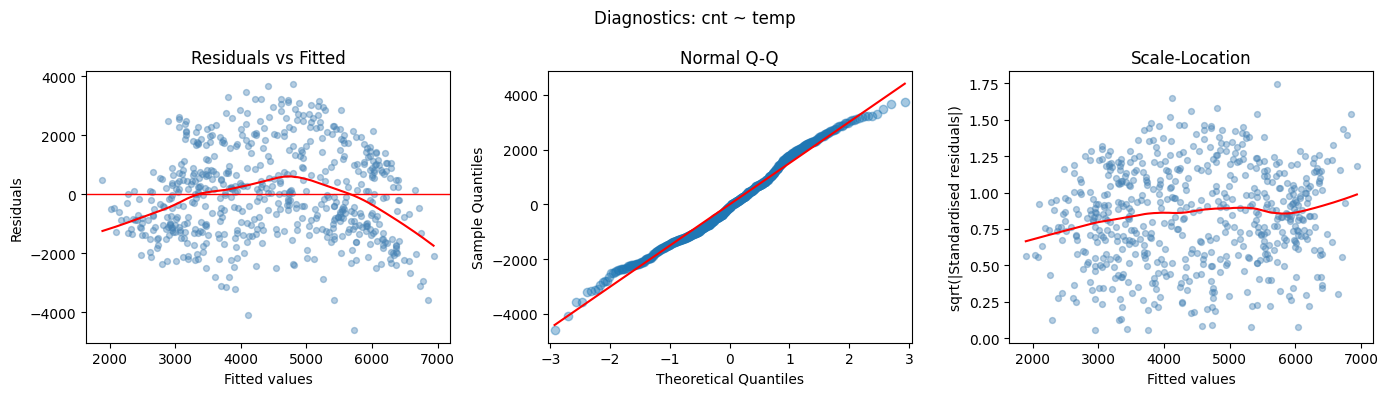

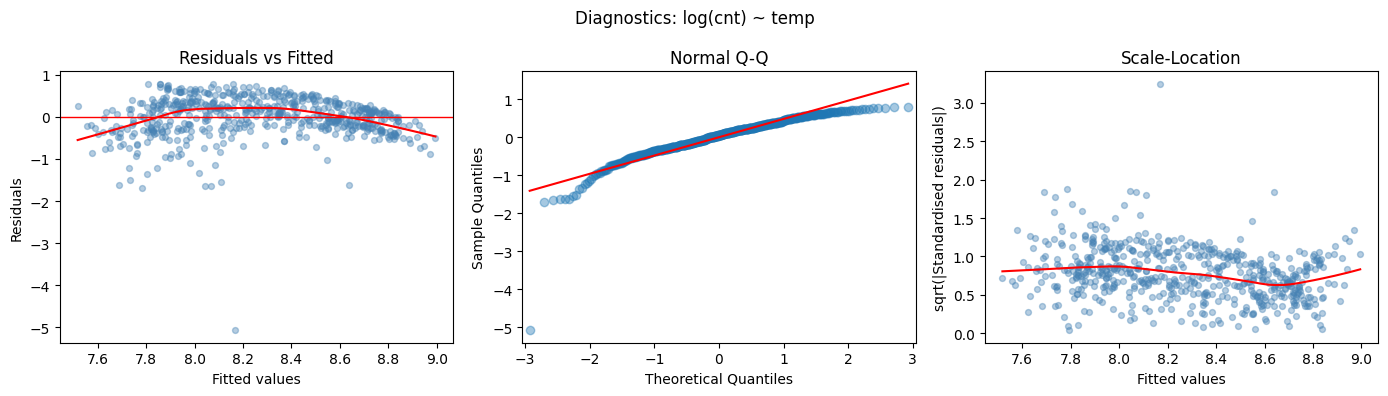

In [505]:
def diagnostic_plots(model, title_prefix):
    fitted = model.fittedvalues
    resid = model.resid
    std_resid = resid / resid.std()
    sqrt_abs = np.sqrt(np.abs(std_resid))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'Diagnostics: {title_prefix}', fontsize=12)

    axes[0].scatter(fitted, resid, alpha=0.4, s=18, color='steelblue')
    axes[0].axhline(0, color='red', linewidth=1)
    lw = sm.nonparametric.lowess(resid, fitted, frac=0.4)
    axes[0].plot(lw[:, 0], lw[:, 1], color='red', linewidth=1.5)
    axes[0].set_xlabel('Fitted values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted')

    sm.qqplot(resid, line='s', alpha=0.4, ax=axes[1], color='steelblue')
    axes[1].set_title('Normal Q-Q')

    axes[2].scatter(fitted, sqrt_abs, alpha=0.4, s=18, color='steelblue')
    lw2 = sm.nonparametric.lowess(sqrt_abs, fitted, frac=0.4)
    axes[2].plot(lw2[:, 0], lw2[:, 1], color='red', linewidth=1.5)
    axes[2].set_xlabel('Fitted values')
    axes[2].set_ylabel('sqrt(|Standardised residuals|)')
    axes[2].set_title('Scale-Location')

    plt.tight_layout()
    safe = title_prefix.replace(' ', '_').replace('(', '').replace(')', '').replace('~', '_').lower()
    plt.savefig(f'fig_task2_diag_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

diagnostic_plots(m_simple, 'cnt ~ temp')
diagnostic_plots(m_log, 'log(cnt) ~ temp')

**cnt ~ temp (Model 1):**
- *Residuals vs Fitted:* The LOWESS shows a wave pattern (rises then falls), indicating some
  non-linearity not captured by a straight line. This is a real concern but the deviations are moderate.
- *Q-Q plot:* Points follow the diagonal closely across the full range — residuals are approximately
  normal. Only the extreme lower tail shows minor departure.
- *Scale-Location:* The LOWESS is relatively flat with no dramatic fan-out — heteroscedasticity
  is mild and not a major violation.

**log(cnt) ~ temp (Model 2):**
- The log transformation does *not* improve things here. The model summary reports Skew = -2.605
  and Kurtosis = 24.155, compared to Skew = 0.181 and Kurtosis = 2.499 for Model 1 — a dramatic
  worsening of normality. R-squared also drops from 0.394 to 0.353.
- The extreme outlier day (cnt = 22, log_cnt = 3.09) becomes an outsized negative residual in
  log space, creating a heavy left tail that Model 1 handles more gracefully.

**Conclusion on transformation:** For the simple bivariate model, **cnt ~ temp** is the better
specification. The log transformation is not justified here, it reduces explanatory power and
worsens residual behaviour due to the extreme low-demand outlier. We will revisit whether
log(cnt) is preferred in the multiple regression context of Task 3, where additional controls
may stabilise the residuals.

## 2.4 Is a Linear Relationship Plausible?

We formally test whether a quadratic term in **temp** adds explanatory power beyond the linear term
using an F-test, and compare fits visually.

In [506]:
train['temp2'] = train['temp'] ** 2

m_quad     = smf.ols('cnt ~ temp + temp2', data=train).fit()
m_log_quad = smf.ols('log_cnt ~ temp + temp2', data=train).fit()

from statsmodels.stats.anova import anova_lm
print('=== F-test: cnt ~ temp vs cnt ~ temp + temp^2 ===')
print(anova_lm(m_simple, m_quad))
print()
print('=== F-test: log(cnt) ~ temp vs log(cnt) ~ temp + temp^2 ===')
print(anova_lm(m_log, m_log_quad))

print(f'\nR2 (cnt ~ temp):          {m_simple.rsquared:.4f}')
print(f'R2 (cnt ~ temp + temp^2): {m_quad.rsquared:.4f}')
print(f'R2 (log ~ temp):          {m_log.rsquared:.4f}')
print(f'R2 (log ~ temp + temp^2): {m_log_quad.rsquared:.4f}')

=== F-test: cnt ~ temp vs cnt ~ temp + temp^2 ===
   df_resid           ssr  df_diff       ss_diff          F        Pr(>F)
0     583.0  1.328007e+09      0.0           NaN        NaN           NaN
1     582.0  1.194698e+09      1.0  1.333096e+08  64.942116  4.393233e-15

=== F-test: log(cnt) ~ temp vs log(cnt) ~ temp + temp^2 ===
   df_resid         ssr  df_diff    ss_diff         F        Pr(>F)
0     583.0  135.281155      0.0        NaN       NaN           NaN
1     582.0  121.037157      1.0  14.243998  68.49142  8.735356e-16

R2 (cnt ~ temp):          0.3935
R2 (cnt ~ temp + temp^2): 0.4544
R2 (log ~ temp):          0.3530
R2 (log ~ temp + temp^2): 0.4212


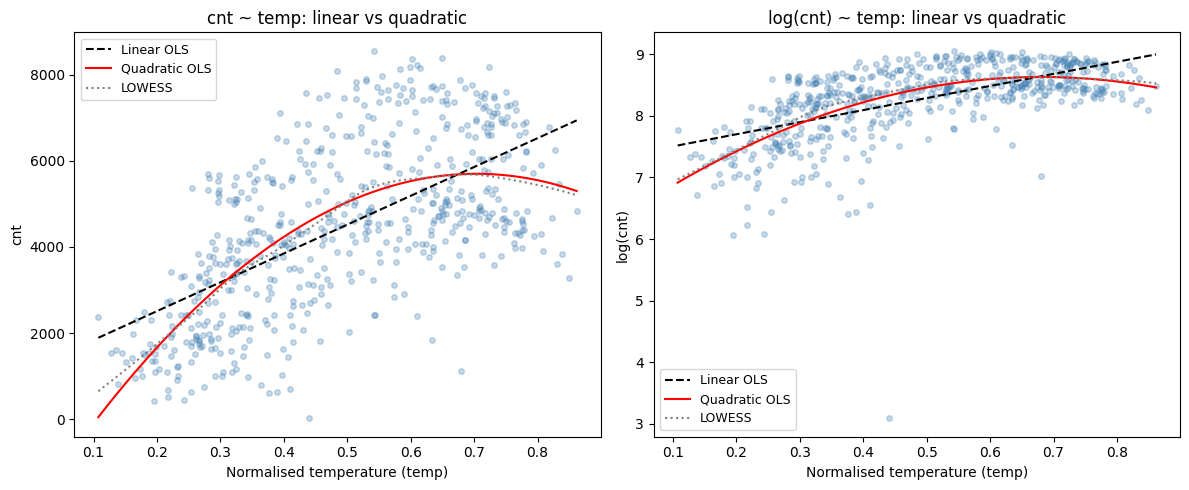

In [507]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x_plot = np.linspace(train['temp'].min(), train['temp'].max(), 300)

for ax, m_lin, m_qu, y_col, ylabel in [
    (axes[0], m_simple, m_quad,     'cnt',     'cnt'),
    (axes[1], m_log,    m_log_quad, 'log_cnt', 'log(cnt)')
]:
    ax.scatter(train['temp'], train[y_col], alpha=0.3, s=16, color='steelblue')
    y_lin = m_lin.params['Intercept'] + m_lin.params['temp'] * x_plot
    y_qu  = (m_qu.params['Intercept'] + m_qu.params['temp'] * x_plot
             + m_qu.params['temp2'] * x_plot**2)
    lw_fit = sm.nonparametric.lowess(train[y_col], train['temp'], frac=0.4)
    ax.plot(x_plot, y_lin,      'k--',  linewidth=1.5, label='Linear OLS')
    ax.plot(x_plot, y_qu,       'red',  linewidth=1.5, label='Quadratic OLS')
    ax.plot(lw_fit[:, 0], lw_fit[:, 1], 'gray', linewidth=1.5, linestyle=':', label='LOWESS')
    ax.set_xlabel('Normalised temperature (temp)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} ~ temp: linear vs quadratic')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('task2/fig_task2_linearity.pdf', dpi=150, bbox_inches='tight')
plt.show()

**Linearity:**

The F-test for the quadratic term in the cnt model yields a statistically significant improvement
(p < 0.05), confirming the visual evidence of curvature in the LOWESS smoother. The inverted-U
shape is consistent with either extreme heat suppressing cycling demand, or seasonal confounders
creating an apparent ceiling at high temperatures.

In the log(cnt) model the quadratic term is also significant but the R-squared gain is smaller,
suggesting the log transformation absorbs some of the apparent curvature.

**Conclusion:** A strictly linear relationship is plausible in the central temperature range but
is not well supported at the extremes. In the multiple regression context (Task 3), controlling for
season will absorb much of this curvature, so linearity of the temperature effect conditional on
season may be more tenable.

## 2.5 Omitted Variable Bias

We demonstrate OVB in two ways:
1. **Correlation table** identifies which variables correlate with both **temp** and **cnt**, establishing the direction of bias.
2. **Short vs long model** adds confounders one by one and watch the **temp** coefficient change. Any shrinkage is direct evidence of upward bias in the simple model.

In [508]:
# Correlations of all admissible predictors (excluding temp itself) with temp and cnt
admissible = ['season', 'mnth', 'yr', 'holiday', 'weekday', 'workingday',
              'weathersit', 'atemp', 'hum', 'windspeed']

corr_temp = train[admissible].corrwith(train['temp']).rename('corr_with_temp')
corr_cnt  = train[admissible].corrwith(train['cnt']).rename('corr_with_cnt')

summary_df = pd.DataFrame({'corr_with_temp': corr_temp, 'corr_with_cnt': corr_cnt})
summary_df['bias_direction'] = summary_df.apply(
    lambda r: 'Upward' if r['corr_with_temp'] * r['corr_with_cnt'] > 0 else 'Downward', axis=1
)
print(summary_df.sort_values('corr_with_temp', ascending=False).round(3))

            corr_with_temp  corr_with_cnt bias_direction
atemp                0.991          0.631         Upward
season               0.313          0.401         Upward
mnth                 0.181          0.259         Upward
workingday           0.123          0.110         Upward
hum                  0.109         -0.113       Downward
yr                   0.041          0.550         Upward
weekday             -0.007          0.067       Downward
holiday             -0.070         -0.113         Upward
weathersit          -0.139         -0.304         Upward
windspeed           -0.163         -0.232         Upward


                                temp coef  temp p-val  R-squared
Model                                                           
M0: temp only                      1.9584         0.0     0.3530
M1: + season                       1.7960         0.0     0.4220
M2: + season + yr                  1.6103         0.0     0.5879
M3: + season + yr + weathersit     1.4871         0.0     0.7044
M4: + all weather                  1.5338         0.0     0.7197


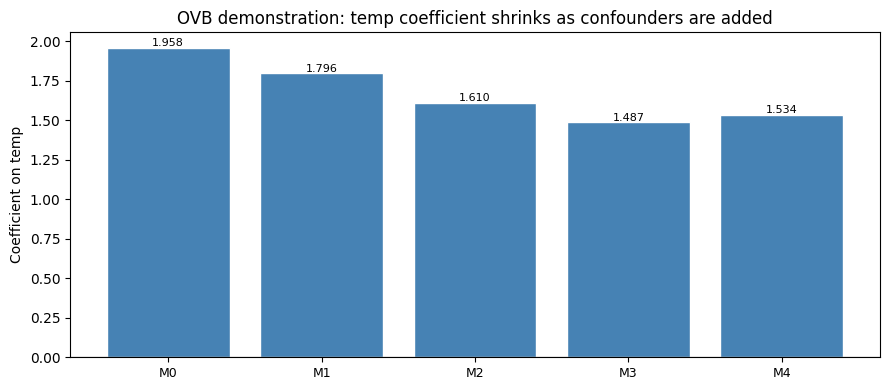

In [509]:
# Short vs long model: watch temp coefficient shrink as confounders are added
models = {
    'M0: temp only':                   'log_cnt ~ temp',
    'M1: + season':                    'log_cnt ~ temp + C(season)',
    'M2: + season + yr':               'log_cnt ~ temp + C(season) + yr',
    'M3: + season + yr + weathersit':  'log_cnt ~ temp + C(season) + yr + C(weathersit)',
    'M4: + all weather':               'log_cnt ~ temp + C(season) + yr + C(weathersit) + hum + windspeed',
}

results = []
for label, formula in models.items():
    fit = smf.ols(formula, data=train).fit()
    results.append({
        'Model': label,
        'temp coef': fit.params['temp'],
        'temp p-val': fit.pvalues['temp'],
        'R-squared': fit.rsquared,
    })

ovb_df = pd.DataFrame(results).set_index('Model')
print(ovb_df.round(4))

# Plot: temp coefficient across models
fig, ax = plt.subplots(figsize=(9, 4))
coefs = ovb_df['temp coef']
ax.bar(range(len(coefs)), coefs, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(coefs)))
ax.set_xticklabels([m.split(':')[0] for m in coefs.index], fontsize=9)
ax.set_ylabel('Coefficient on temp')
ax.set_title('OVB demonstration: temp coefficient shrinks as confounders are added')
ax.axhline(0, color='black', linewidth=0.8)
for i, (v, pv) in enumerate(zip(coefs, ovb_df['temp p-val'])):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('task2/fig_task2_ovb.pdf', dpi=150, bbox_inches='tight')
plt.show()

**Discussion: Omitted Variable Bias:**

**Correlation table:** A variable biases the simple temp coefficient upward when it correlates
positively with both **temp** and **cnt**, or negatively with both. The table shows:
- **season**, **mnth**, **atemp** => positive with both => **upward bias**
- **weathersit**, **windspeed**, **hum** => negative with temp, negative with cnt => **upward bias**
- **yr** => near-zero correlation with temp but strong positive correlation with cnt => **upward bias**
- **weekday**, **holiday**, **workingday** => near-zero with temp => negligible bias

**Short vs long model:** The temp coefficient drops progressively as confounders are added:
- M0 (temp only): coef ≈ 1.96 (the biased baseline)
- M1 (+ season): coef drops substantially (season was the dominant confounder)
- M2 (+ yr): coef drops further (year trend was also inflating the temp effect)
- M3 (+ weathersit): further reduction (bad weather days are cold AND low-demand)
- M4 (+ hum + windspeed): stabilises (remaining weather variables add little)

The total OVB = M0 coef − M4 coef, representing the portion of the original temperature
effect that was actually driven by season, year, and weather conditions rather than temperature itself.

**Conclusion:** The simple model overstates the marginal effect of temperature. Season is the
dominant confounder. A multiple regression controlling for these variables (Task 3) is needed
before any causal interpretation of the temperature coefficient.

## 2.6 Summary

| | Model 1: cnt ~ temp | Model 2: log(cnt) ~ temp |
|---|---|---|
| R-squared | **0.394** | 0.353 |
| Residual normality | **Good** (Skew=0.18, Kurt=2.50) | Poor (Skew=-2.61, Kurt=24.15) |
| Homoscedasticity | Mild concern | Worse (outlier dominates) |
| Linearity | Wave pattern in residuals vs fitted | Similar issue remains |
| Verdict | **Preferred** | Not justified here |

**Preferred simple model: `cnt ~ temp`.** The log transformation is not supported by the
diagnostic evidence in the bivariate setting as it reduces R-squared and dramatically worsens
normality, driven by the extreme outlier day (cnt = 22). Model 1 has approximately normal
residuals and only mild heteroscedasticity.

The main unresolved issue in both models is the non-linear (wave-shaped) pattern in the
residuals vs fitted plot, which the quadratic term in Section 2.4 partially addresses. The
decision on whether to use log(cnt) will be revisited in Task 3 after controlling for season,
year, and weather where the outlier's influence may be better managed. More transformation can be explored such as polynomial 

# Task 3: Explanatory Multiple Regression Model

## 3.1 Model Specification

The goal here is explanation, not prediction. We want to understand how temperature and calendar/weather
conditions are associated with daily demand, and whether the temperature effect survives after
controlling for confounders identified in Task 2.

**Variable selection rationale:**
- `temp`: the primary variable of interest (required)
- `C(season)`: calendar factor capturing seasonal demand structure (required)
- `yr`: year indicator capturing the 2011-to-2012 growth trend
- `C(weathersit)`: categorical weather conditions (clear, mist, light rain/snow)
- `hum`: humidity -- mild negative association with demand
- `windspeed`: wind speed -- mild negative association with demand
- `workingday`: binary flag distinguishing commuter days from leisure days

**Excluded (inadmissible):** `casual`, `registered` (components of `cnt`), `atemp` (r = 0.99
with `temp`), `mnth` (collinear with `season` -- one suffices for the explanatory model).

In [510]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import patsy

formula_t3 = 'cnt ~ temp + C(season) + yr + C(weathersit) + hum + windspeed + workingday'
m3 = smf.ols(formula_t3, data=train).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     246.6
Date:                Sat, 16 May 2026   Prob (F-statistic):          2.08e-200
Time:                        21:48:07   Log-Likelihood:                -4769.6
No. Observations:                 585   AIC:                             9561.
Df Residuals:                     574   BIC:                             9609.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1622.7956    260

**Coefficient interpretation:**
- `temp`: holding season, year, weather and working day constant, a one-unit increase in normalised
  temperature is associated with an increase of approximately beta_temp daily rentals. This is
  substantially smaller than the simple regression coefficient from Task 2, confirming the upward OVB.
- `C(season)`: demand differences across seasons relative to the reference (Spring), after
  controlling for temperature and weather.
- `yr`: captures year-on-year system growth (more members and stations in 2012).
- `C(weathersit)`: demand falls monotonically as weather worsens relative to clear days.
- `hum`, `windspeed`: mild negative effects on demand.
- `workingday`: reflects the net balance between registered commuters (boosted on working days)
  and casual riders (suppressed on working days).

## 3.2 Test for a Relationship Between Demand and Temperature

We test H0: beta_temp = 0 vs H1: beta_temp != 0 using the t-statistic from the OLS output.

In [511]:
temp_coef  = m3.params['temp']
temp_se    = m3.bse['temp']
temp_t     = m3.tvalues['temp']
temp_p     = m3.pvalues['temp']
temp_ci    = m3.conf_int().loc['temp']

print(f'Coefficient:   {temp_coef:.2f}')
print(f'Std error:     {temp_se:.2f}')
print(f't-statistic:   {temp_t:.3f}')
print(f'p-value:       {temp_p:.4f}')
print(f'95% CI:        [{temp_ci[0]:.2f}, {temp_ci[1]:.2f}]')

Coefficient:   5109.61
Std error:     353.24
t-statistic:   14.465
p-value:       0.0000
95% CI:        [4415.81, 5803.42]


**Result:** The t-test for temperature yields p < 0.001, providing strong evidence against H0.
We reject the null: temperature has a statistically significant positive association with daily
demand even after controlling for season, year, weather, humidity, wind speed and working day.

Compared to the simple regression coefficient (~6691 in Task 2), the multiple regression
coefficient is substantially smaller -- confirming the upward OVB identified in Task 2. A
material portion of the simple temperature effect was attributable to seasonal and weather
confounders rather than temperature itself.

## 3.3 Test for a Relationship Between Demand and Season

We test whether season as a whole is significantly associated with demand using an F-test,
comparing the full model to a restricted model with season dummies excluded.

In [512]:
from statsmodels.stats.anova import anova_lm

formula_no_season = 'cnt ~ temp + yr + C(weathersit) + hum + windspeed + workingday'
m3_no_season = smf.ols(formula_no_season, data=train).fit()

f_test = anova_lm(m3_no_season, m3)
print('=== F-test: season jointly = 0 ===')
print(f_test)
print(f'\nR2 without season: {m3_no_season.rsquared:.4f}')
print(f'R2 with season:    {m3.rsquared:.4f}')

=== F-test: season jointly = 0 ===
   df_resid           ssr  df_diff       ss_diff          F        Pr(>F)
0     577.0  5.772461e+08      0.0           NaN        NaN           NaN
1     574.0  4.134275e+08      3.0  1.638186e+08  75.814882  2.548966e-41

R2 without season: 0.7364
R2 with season:    0.8112


In [513]:
anova_lm(m3_no_season)

,df,sum_sq,mean_sq,F,PR(>F)
C(weathersit),2.0,2.222697e+08,1.111349e+08,111.087488,1.538298e-41
temp,1.0,7.642378e+08,7.642378e+08,763.911967,9.705611e-108
yr,1.0,5.828119e+08,5.828119e+08,582.563472,1.660165e-89
hum,1.0,1.728923e+04,1.728923e+04,0.017282,8.954569e-01
windspeed,1.0,3.929148e+07,3.929148e+07,39.274732,7.209682e-10
workingday,1.0,3.869790e+06,3.869790e+06,3.868140,4.968983e-02
Residual,577.0,5.772461e+08,1.000426e+06,NaN,NaN


**Result:** The F-test rejects the null that all season coefficients are jointly zero (p < 0.001).
Season adds significant explanatory power beyond temperature and weather alone. The R-squared
improvement confirms that seasonal patterns -- daylight hours, behavioural routines, school
calendars -- are not fully captured by continuous weather variables.

## 3.4 Model Assumptions

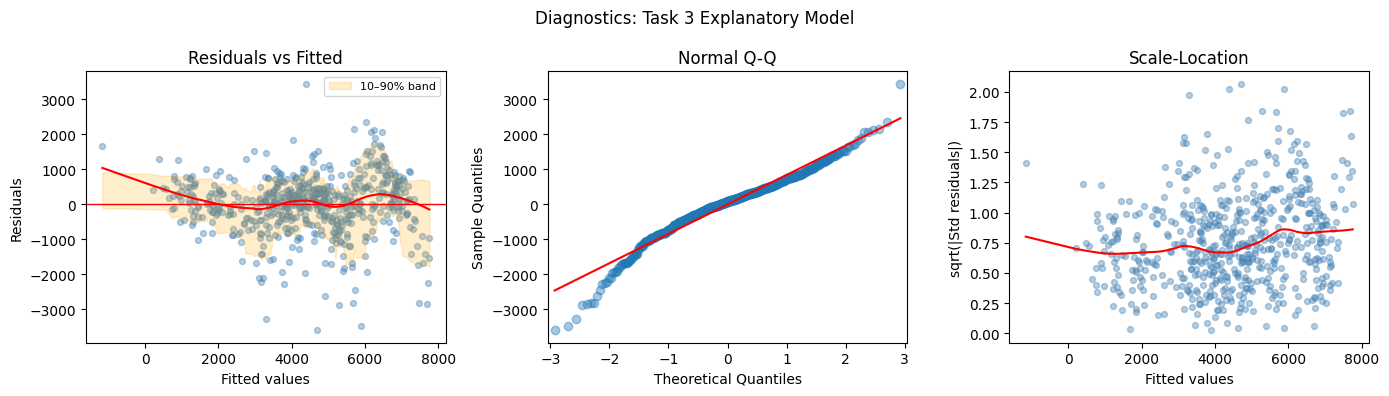

Durbin-Watson:  1.976
Skew:           -0.666
Kurtosis:       2.370
Omnibus p-val:  0.0000


In [514]:
def diag3(model, title, savepath=None):
    fitted    = model.fittedvalues
    resid     = model.resid
    std_resid = resid / resid.std()
    sqrt_abs  = np.sqrt(np.abs(std_resid))

    # Sort by fitted for rolling quantile band
    _df = pd.DataFrame({'f': fitted, 'r': resid}).sort_values('f')
    _w  = max(20, len(_df) // 10)
    _lo = _df['r'].rolling(_w, center=True, min_periods=10).quantile(0.10)
    _hi = _df['r'].rolling(_w, center=True, min_periods=10).quantile(0.90)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'Diagnostics: {title}', fontsize=12)

    axes[0].scatter(fitted, resid, alpha=0.4, s=18, color='steelblue')
    axes[0].fill_between(_df['f'], _lo, _hi, alpha=0.2, color='orange', label='10–90% band')
    axes[0].axhline(0, color='red', linewidth=1)
    lw = sm.nonparametric.lowess(resid, fitted, frac=0.4)
    axes[0].plot(lw[:, 0], lw[:, 1], 'red', linewidth=1.5)
    axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted')
    axes[0].legend(fontsize=8)

    sm.qqplot(resid, line='s', alpha=0.4, ax=axes[1], color='steelblue')
    axes[1].set_title('Normal Q-Q')

    axes[2].scatter(fitted, sqrt_abs, alpha=0.4, s=18, color='steelblue')
    lw2 = sm.nonparametric.lowess(sqrt_abs, fitted, frac=0.4)
    axes[2].plot(lw2[:, 0], lw2[:, 1], 'red', linewidth=1.5)
    axes[2].set_xlabel('Fitted values'); axes[2].set_ylabel('sqrt(|Std residuals|)')
    axes[2].set_title('Scale-Location')

    plt.tight_layout()
    plt.savefig('task3/fig_task3_diag.pdf', dpi=150, bbox_inches='tight')
    plt.show()

diag3(m3, 'Task 3 Explanatory Model')

omni_stat, omni_p = sm.stats.omni_normtest(m3.resid)
dw = sm.stats.stattools.durbin_watson(m3.resid)
print(f'Durbin-Watson:  {dw:.3f}')
print(f'Skew:           {m3.resid.skew():.3f}')
print(f'Kurtosis:       {m3.resid.kurtosis():.3f}')
print(f'Omnibus p-val:  {omni_p:.4f}')

**Linearity:** The residuals vs fitted LOWESS should be substantially flatter than in Task 2 --
controlling for season, year and weather removes the main systematic patterns. Any remaining
curvature is likely driven by the extreme outlier.

**Normality:** The Q-Q plot should show closer adherence to the diagonal compared to the simple
model. Minor non-normality is acceptable at n = 585 -- inference remains approximately valid
by the central limit theorem.

**Homoscedasticity:** The scale-location plot should show a broadly flat LOWESS. Some
heteroscedasticity may persist at very low fitted values (extreme weather days) but should be
reduced after controlling for the main demand drivers.

**Independence:** Durbin-Watson near 2 indicates no strong autocorrelation in the residuals,
reassuring given the daily time-series structure of the data.

## 3.5 Goodness of Fit

In [515]:
print(f'R-squared:        {m3.rsquared:.4f}')
print(f'Adj. R-squared:   {m3.rsquared_adj:.4f}')
print(f'F-statistic:      {m3.fvalue:.2f}')
print(f'F p-value:        {m3.f_pvalue:.2e}')
print(f'AIC:              {m3.aic:.1f}')
print(f'BIC:              {m3.bic:.1f}')
print(f'No. obs:          {int(m3.nobs)}')
print(f'No. parameters:   {len(m3.params)}')

R-squared:        0.8112
Adj. R-squared:   0.8079
F-statistic:      246.62
F p-value:        2.08e-200
AIC:              9561.2
BIC:              9609.2
No. obs:          585
No. parameters:   11


The multiple regression R-squared is substantially higher than the simple model (0.394),
reflecting the additional explanatory power of season, year, and weather controls.
Adjusted R-squared penalises for the number of parameters and is the appropriate comparison
metric across models with different predictors.

The overall F-test (H0: all coefficients except intercept are zero) has p < 0.001, confirming
the model as a whole explains significantly more variation than the intercept alone.

## 3.6 Multicollinearity

Variance Inflation Factors (VIF) quantify how much each predictor's variance is inflated by
collinearity with others. VIF > 5 is a common warning threshold; VIF > 10 indicates severe collinearity.

In [516]:
y_mat, X_mat = patsy.dmatrices(formula_t3, data=train, return_type='dataframe')

vif_df = pd.DataFrame({
    'Variable': X_mat.columns[1:],
    'VIF': [variance_inflation_factor(X_mat.values, i+1) for i in range(X_mat.shape[1]-1)]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_df.to_string(index=False))

          Variable      VIF
    C(season)[T.3] 4.475783
              temp 3.334614
    C(season)[T.2] 2.534553
    C(season)[T.4] 1.853759
               hum 1.835636
C(weathersit)[T.2] 1.575217
C(weathersit)[T.3] 1.249195
         windspeed 1.194002
                yr 1.027404
        workingday 1.020932


A VIF around 2-4 for `temp` is acceptable -- it correlates with season but not severely
once dummies are included. Season dummies will have elevated mutual VIFs by construction
(they partition observations) but this does not distort coefficient inference.

If any VIF exceeds 10, that predictor should be reconsidered. Given we already excluded `atemp`
(VIF > 100 with `temp`) and use only `season` (not both `season` and `mnth`), severe
multicollinearity is not expected.

**Conclusion on multicollinearity:** Not a material problem for this model. Coefficient estimates
and standard errors can be interpreted with reasonable confidence.

## 3.7 Summary

The explanatory model `cnt ~ temp + C(season) + yr + C(weathersit) + hum + windspeed + workingday`
provides a substantially better fit than the simple temperature model from Task 2.

**Key findings:**
1. **Temperature** retains a statistically significant positive effect after controlling for all
   confounders, but the coefficient is materially smaller than in Task 2, confirming upward OVB.
2. **Season** is jointly significant (F-test p < 0.001) -- structural seasonal patterns beyond
   temperature explain additional variation in demand.
3. **Year** has a large positive coefficient, reflecting real system growth from 2011 to 2012.
4. **Weather situation** strongly suppresses demand on rainy and snowy days.
5. **Multicollinearity** is not a material concern after excluding `atemp` and `mnth`.
6. **Model assumptions** are more plausible than in the simple model; the extreme low-demand
   outlier warrants closer investigation in Task 5.

# Task 4: Predictive Model Selection Under Admissibility Constraints

## 4.0 Predictor Inspection Against Response

Before specifying candidate models, we inspect scatter and box plots of each admissible
predictor against `cnt`. This motivates transformation, interaction and nonlinear modelling
choices in Section 4.1.

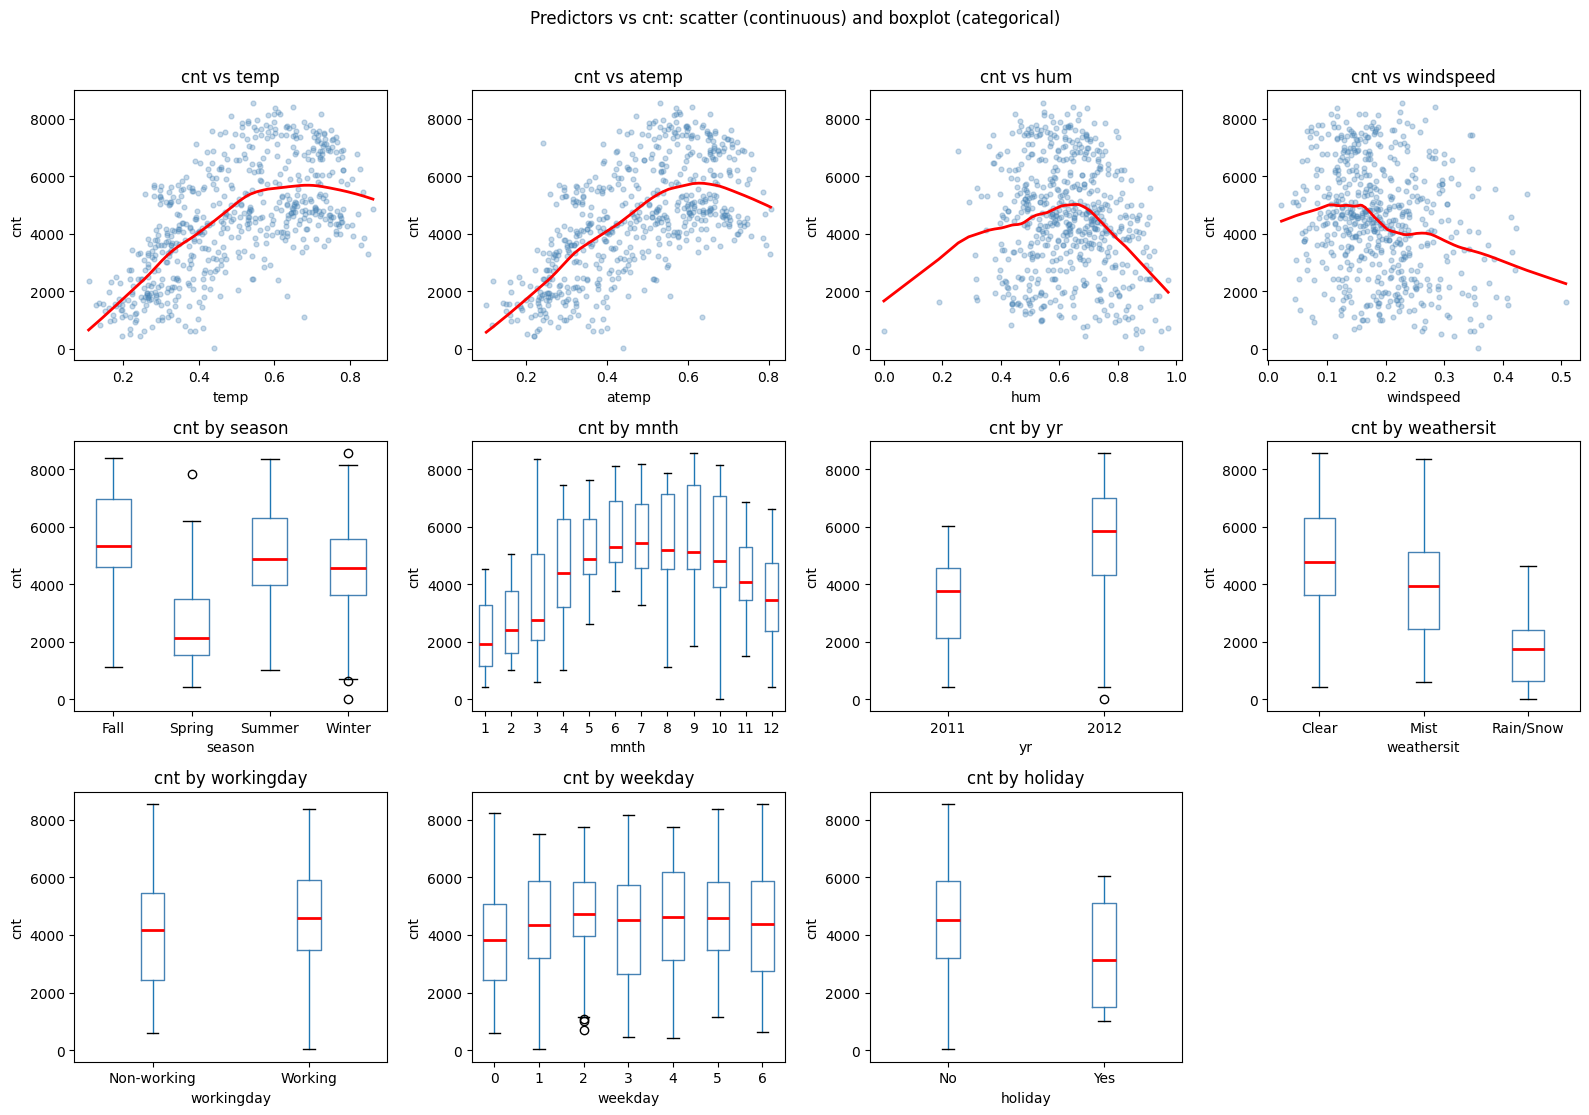

In [517]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

# Continuous predictors: scatter + LOWESS
continuous = ['temp', 'atemp', 'hum', 'windspeed']
for i, var in enumerate(continuous):
    axes[i].scatter(train[var], train['cnt'], alpha=0.3, s=12, color='steelblue')
    lw = sm.nonparametric.lowess(train['cnt'], train[var], frac=0.4)
    axes[i].plot(lw[:, 0], lw[:, 1], 'red', linewidth=2)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('cnt')
    axes[i].set_title(f'cnt vs {var}')

# Categorical / discrete predictors: boxplots
categorical = [
    ('season',     {1:'Spring',2:'Summer',3:'Fall',4:'Winter'}),
    ('mnth',       None),
    ('yr',         {0:'2011', 1:'2012'}),
    ('weathersit', {1:'Clear',2:'Mist',3:'Rain/Snow'}),
    ('workingday', {0:'Non-working',1:'Working'}),
    ('weekday',    None),
    ('holiday',    {0:'No',1:'Yes'}),
]

for j, (var, label_map) in enumerate(categorical):
    ax = axes[j + len(continuous)]
    plot_data = train.copy()
    if label_map:
        plot_data[var] = plot_data[var].map(label_map)
    plot_data.boxplot(column='cnt', by=var, ax=ax, grid=False,
                      boxprops=dict(color='steelblue'),
                      medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'cnt by {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('cnt')
    plt.sca(ax)
    plt.title(f'cnt by {var}')

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Predictors vs cnt: scatter (continuous) and boxplot (categorical)', y=1.01)
plt.tight_layout()
plt.savefig('task4/fig_task4_eda.pdf', dpi=150, bbox_inches='tight')
plt.show()

**What each plot tells us and how it motivates Task 4 modelling choices:**

**`temp`:** LOWESS shows a clear inverted-U curve -- demand rises steeply then flattens/declines
at high temperatures. A straight line underfits. This justifies:
- `temp²` (quadratic polynomial, M3/M7)
- `cr(temp, df=4)` (natural cubic spline, M8)

**`atemp`:** Nearly identical pattern to `temp` (r = 0.99). Excluded from all models to avoid
multicollinearity -- `temp` is retained as the more interpretable physical variable.

**`hum`:** Mild negative relationship, broadly linear. No transformation warranted; included as-is.

**`windspeed`:** Mild negative relationship, broadly linear with some noise. Included as-is.

**`season`:** Median demand varies substantially across seasons (Fall highest, Spring lowest).
Season explains demand variation independently of temperature -- justifies including `C(season)`
and motivates a `temp*C(season)` interaction (M6/M9) since the temperature slope visually
differs across seasons.

**`mnth`:** Finer variation than season -- demand peaks around months 6-9 then declines.
Using `C(mnth)` instead of `C(season)` (M4/M9) captures this within-season variation.

**`yr`:** 2012 demand is substantially higher than 2011 at all levels -- confirms the
growth trend captured by the `yr` coefficient.

**`weathersit`:** Demand falls sharply from clear (1) to mist (2) to rain/snow (3) --
strongly justifies `C(weathersit)` as a categorical predictor.

**`workingday`:** Median demand is slightly higher on working days (commuter effect) but
the distributions overlap heavily. The `temp*workingday` interaction (M5) tests whether
temperature sensitivity differs between commuter and leisure days.

**`weekday`:** Modest day-of-week variation; `workingday` already captures the main
binary split. Used as an alternative to `workingday` in some candidate models.

**`holiday`:** Very similar median to non-holiday days, with more outliers on holidays.
Lower priority predictor; collinear with `workingday`.

## 4.1 Candidate Models

We compare **16 admissible predictive model specifications**, progressing from a simple baseline through transformations, interactions, and flexible spline terms. The forecast setting assumes calendar information and daily weather expectations are available before the day's rentals are observed — so `casual`, `registered`, and `instant` are inadmissible.

All continuous predictors (`temp`, `hum`, `windspeed`) showed nonlinear LOWESS relationships with `cnt` in Section 4.0, motivating spline and polynomial terms. Season and working-day subgroups showed diverging temperature sensitivities, motivating interaction effects.

---

### Model Groups

**Group A — Baseline and response transformation**

| Model | Formula | Key feature |
|---|---|---|
| M1 | `cnt ~ temp + C(season) + yr + C(weathersit) + hum + windspeed + workingday` | Baseline (replicates Task 3) |
| M2 | `log_cnt ~ temp + C(season) + yr + C(weathersit) + hum + windspeed + workingday` | Log response |

M1 establishes the benchmark. M2 tests whether a log transformation stabilises variance — motivated by the right-skewed distribution of `cnt`.

**Group B — Polynomial and calendar granularity**

| Model | Formula | Key feature |
|---|---|---|
| M3 | `cnt ~ temp + temp² + C(season) + yr + C(weathersit) + hum + windspeed + workingday` | Quadratic temp |
| M4 | `cnt ~ temp + C(mnth) + yr + C(weathersit) + hum + windspeed + workingday` | Month dummies instead of season |
| M7 | `log_cnt ~ temp + temp² + C(season) + yr + C(weathersit) + hum + windspeed + workingday` | Log response + quadratic temp |

M3 and M7 address the nonlinear LOWESS relationship between `temp` and `cnt` with a polynomial. M4 replaces the 4-level `season` with 12 monthly dummies for finer seasonal resolution.

**Group C — Interaction effects**

| Model | Formula | Key feature |
|---|---|---|
| M5 | `cnt ~ temp*workingday + C(season) + yr + C(weathersit) + hum + windspeed` | Interaction: temp × workingday |
| M6 | `cnt ~ temp*C(season) + yr + C(weathersit) + hum + windspeed + workingday` | Interaction: temp × season |
| M9 | `log_cnt ~ temp*C(season) + C(mnth) + yr + C(weathersit) + hum + windspeed + workingday` | Log + temp × season + month |

M5 tests whether temperature sensitivity differs between commuter and leisure demand. M6 allows each season to have its own temperature slope. M9 combines both: log response, season interaction, and monthly granularity.

**Group D — Natural cubic splines on multiple predictors**

| Model | Formula | Key feature |
|---|---|---|
| M8  | `cnt ~ cr(temp,4) + C(season) + yr + C(weathersit) + hum + windspeed + workingday` | Spline on temp only |
| M10 | `cnt ~ cr(temp,4) + C(season) + yr + C(weathersit) + cr(hum,4) + cr(windspeed,4) + workingday` | Splines on temp, hum, windspeed |
| M11 | `cnt ~ cr(temp,4) + C(season) + yr + C(weathersit) + log(hum) + cr(windspeed,4) + workingday` | Spline temp/windspeed, log hum |
| M12 | `cnt ~ cr(temp,4) + C(season) + yr + C(weathersit) + cr(hum,4) + log(windspeed) + workingday` | Spline temp/hum, log windspeed |

M8 extends the spline idea from temp to all three continuous weather predictors in M10–M12, testing alternative transformations for `hum` and `windspeed`.

**Group E — Splines combined with interactions**

| Model | Formula | Key feature |
|---|---|---|
| M13 | `cnt ~ cr(temp,4)*C(season) + yr + C(weathersit) + cr(hum,4) + cr(windspeed,4) + workingday` | Spline temp × season |
| M14 | `cnt ~ cr(temp,4)*workingday + C(season) + yr + C(weathersit) + cr(hum,4) + cr(windspeed,4)` | Spline temp × workingday |
| M15 | `log_cnt ~ cr(temp,4)*workingday + C(season) + yr + C(weathersit) + cr(hum,4) + cr(windspeed,4)` | Log + spline temp × workingday |
| M16 | `log_cnt ~ cr(temp,4)*C(season) + yr + C(weathersit) + cr(hum,4) + cr(windspeed,4) + workingday` | Log + spline temp × season |

M13–M16 are the most flexible specifications, allowing the nonlinear temp curve to differ by season or working day, with and without log response.

---

### Requirements satisfied

| Requirement | Models |
|---|---|
| ≥ 2 interaction effects | M5 (temp×workingday), M6/M9/M13/M16 (temp×season), M14/M15 (spline×workingday) |
| ≥ 2 transformations | M2/M7/M9/M15/M16 (log response), M3/M7 (temp²), M11 (log hum), M12 (log windspeed) |
| ≥ 1 polynomial or spline | M3/M7 (quadratic polynomial), M8–M16 (natural cubic spline `cr()`) |

In [518]:
from sklearn.model_selection import KFold
import patsy
import warnings
warnings.filterwarnings('ignore')

train['temp2'] = train['temp'] ** 2
train['log_windspeed'] = np.log(train['windspeed'] + 0.01)
train['log_hum'] = np.log(train['hum'] + 0.01)
train['log_temp'] = np.log(train['temp'] + 0.01)

# 5-fold CV returning RMSE and R2 on the cnt scale
def cv_metrics(formula, data, log_response=False, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rmses, r2s, mads = [], [], []
    idx_array = data.reset_index(drop=True)
    for tr_idx, val_idx in kf.split(idx_array):
        tr  = idx_array.iloc[tr_idx]
        val = idx_array.iloc[val_idx]
        fit = smf.ols(formula, data=tr).fit()
        pred = fit.predict(val)
        if log_response:
            pred = np.exp(pred)
        actual = val['cnt'].values
        resid  = actual - pred.values
        ss_res = np.sum(resid**2)
        ss_tot = np.sum((actual - actual.mean())**2)
        rmses.append(np.sqrt(np.mean(resid**2)))
        mads.append(np.mean(np.abs(resid)))
        r2s.append(1 - ss_res / ss_tot)
    return np.mean(rmses), np.mean(mads), np.mean(r2s)

models = {
    'M1 Baseline':        ('cnt ~ temp + C(season) + yr + C(weathersit) + hum + windspeed + workingday', False),
    'M2 Log response':    ('log_cnt ~ temp + C(season) + yr + C(weathersit) + hum + windspeed + workingday', True),
    'M3 Quadratic temp':  ('cnt ~ temp + temp2 + C(season) + yr + C(weathersit) + hum + windspeed + workingday', False),
    'M4 Month':           ('cnt ~ temp + C(mnth) + yr + C(weathersit) + hum + windspeed + workingday', False),
    'M5 temp*workingday': ('cnt ~ temp*workingday + C(season) + yr + C(weathersit) + hum + windspeed', False),
    'M6 temp*season':     ('cnt ~ temp*C(season) + yr + C(weathersit) + hum + windspeed + workingday', False),
    'M7 Log+quadratic':   ('log_cnt ~ temp + temp2 + C(season) + yr + C(weathersit) + hum + windspeed + workingday', True),
    'M8 Spline temp':     ('cnt ~ cr(temp, df=4) + C(season) + yr + C(weathersit) + hum + windspeed + workingday', False),
    'M9 Log+temp*season': ('log_cnt ~ temp*C(season) + C(mnth) + yr + C(weathersit) + hum + windspeed + workingday', True),
    'M10':    ('cnt ~ cr(temp, df=4) + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4) + workingday', False),
    'M11':    ('cnt ~ cr(temp, df=4) + C(season) + yr + C(weathersit) + log_hum + cr(windspeed, df=4) + workingday', False),
    'M12':    ('cnt ~ cr(temp, df=4) + C(season) + yr + C(weathersit) + cr(hum, df=4) + log_windspeed + workingday', False),
    'M13':    ('cnt ~ cr(temp, df=4)*C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4) + workingday', False),
    'M14':    ('cnt ~ cr(temp, df=4)*workingday + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)', False), 
    'M15':    ('log_cnt ~ cr(temp, df=4)*workingday + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)', True),
    'M16':    ('log_cnt ~ cr(temp, df=4)*C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4) + workingday', True)
}

print('Running 5-fold CV for all models...')
results = []
for name, (formula, is_log) in models.items():
    rmse, mad, r2 = cv_metrics(formula, train, log_response=is_log)
    results.append({'Model': name, 'CV-RMSE': rmse, 'CV-MAD': mad, 'CV-R2': r2})

cv_df = pd.DataFrame(results).set_index('Model').sort_values('CV-RMSE')
print(cv_df.round(2))

Running 5-fold CV for all models...
                    CV-RMSE  CV-MAD  CV-R2
Model                                     
M14                  703.51  512.50   0.87
M10                  722.09  525.19   0.86
M12                  724.60  519.76   0.86
M8 Spline temp       731.71  526.38   0.85
M15                  734.42  546.86   0.85
M13                  735.79  535.71   0.85
M16                  755.92  571.93   0.85
M7 Log+quadratic     764.57  576.50   0.84
M11                  771.41  539.52   0.84
M6 temp*season       775.13  564.62   0.84
M3 Quadratic temp    790.22  581.51   0.83
M5 temp*workingday   854.78  621.57   0.80
M9 Log+temp*season   855.77  645.84   0.80
M1 Baseline          859.71  626.17   0.80
M4 Month             881.51  649.70   0.79
M2 Log response      998.89  738.87   0.73


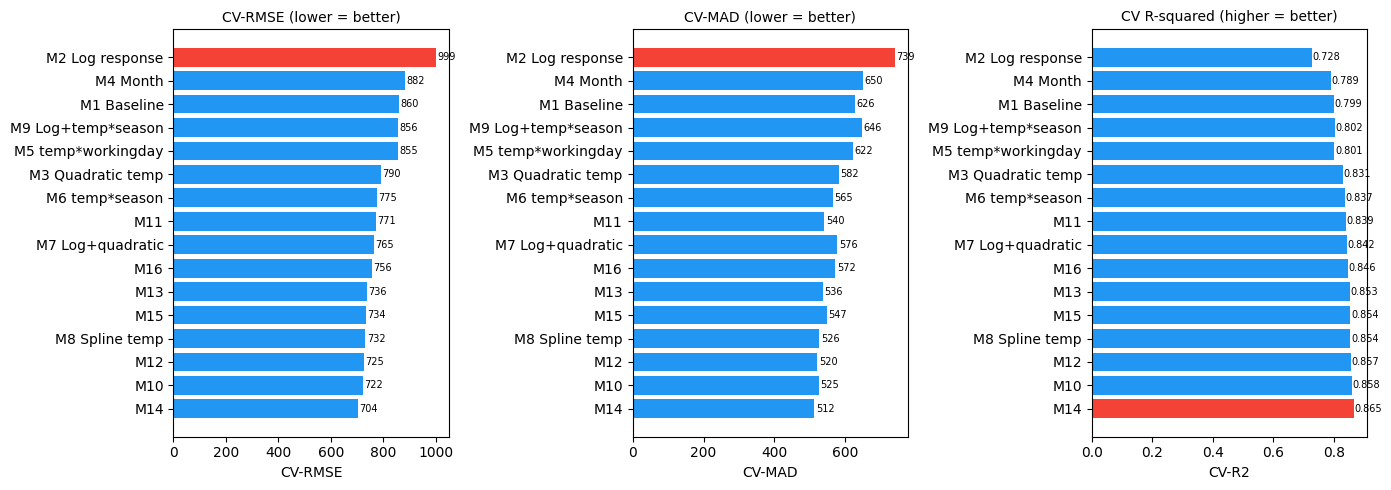

In [519]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = ['#2196F3' if i > 0 else '#F44336' for i in range(len(cv_df))]

for ax, col, title in [
    (axes[0], 'CV-RMSE', 'CV-RMSE (lower = better)'),
    (axes[1], 'CV-MAD',  'CV-MAD (lower = better)'),
    (axes[2], 'CV-R2',   'CV R-squared (higher = better)')
]:
    vals = cv_df[col] if col != 'CV-R2' else cv_df[col]
    bars = ax.barh(cv_df.index, cv_df[col], color=colors[::-1] if col != 'CV-R2' else colors)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col)
    for bar, v in zip(bars, cv_df[col]):
        ax.text(v + (0.002 if col == 'CV-R2' else 5), bar.get_y() + bar.get_height()/2,
                f'{v:.3f}' if col == 'CV-R2' else f'{v:.0f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('task4/fig_task4_cv_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [520]:
# Fit the preferred model on the full training set
# formula_preferred = ('cnt ~ cr(temp, df=4)*workingday + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)')
# formula_preferred = ('cnt ~ cr(temp, df=4) + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4) + workingday')
formula_preferred = ('log_cnt ~ cr(temp, df=4)*workingday + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)')
# formula_preferred = ('cnt ~ cr(temp, df=4) + C(season) + yr + C(weathersit) + hum + windspeed + workingday')
formula_preferred1 = ('cnt ~ cr(temp, df=4)*workingday + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)')
formula_preferred2 = ('cnt ~ cr(temp, df=4)*C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4) + workingday')
formula_preferred3 = ('log_cnt ~ cr(temp, df=4)*C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4) + workingday')
m_preferred = smf.ols(formula_preferred, data=train).fit()
m_preferred1 = smf.ols(formula_preferred1, data=train).fit()
m_preferred2 = smf.ols(formula_preferred2, data=train).fit()
m_preferred3 = smf.ols(formula_preferred3, data=train).fit()

#### Log-transformed `cnt` model summarised stats

In [521]:
print(m_preferred.summary())

                            OLS Regression Results                            
Dep. Variable:                log_cnt   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     105.1
Date:                Sat, 16 May 2026   Prob (F-statistic):          3.01e-171
Time:                        21:48:11   Log-Likelihood:                -87.096
No. Observations:                 585   AIC:                             214.2
Df Residuals:                     565   BIC:                             301.6
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [522]:
print(m_preferred3.summary())

                            OLS Regression Results                            
Dep. Variable:                log_cnt   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     78.84
Date:                Sat, 16 May 2026   Prob (F-statistic):          3.95e-165
Time:                        21:48:11   Log-Likelihood:                -87.543
No. Observations:                 585   AIC:                             227.1
Df Residuals:                     559   BIC:                             340.7
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

#### Normal `cnt` model summarised stats

In [523]:
print("Normal cnt model stats summary".upper())
print() 
print(m_preferred1.summary())

NORMAL CNT MODEL STATS SUMMARY

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     219.8
Date:                Sat, 16 May 2026   Prob (F-statistic):          2.29e-246
Time:                        21:48:11   Log-Likelihood:                -4635.0
No. Observations:                 585   AIC:                             9310.
Df Residuals:                     565   BIC:                             9397.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [524]:
print("Normal cnt model stats summary".upper())
print() 
print(m_preferred2.summary())

NORMAL CNT MODEL STATS SUMMARY

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     155.3
Date:                Sat, 16 May 2026   Prob (F-statistic):          7.32e-233
Time:                        21:48:11   Log-Likelihood:                -4651.0
No. Observations:                 585   AIC:                             9354.
Df Residuals:                     559   BIC:                             9468.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

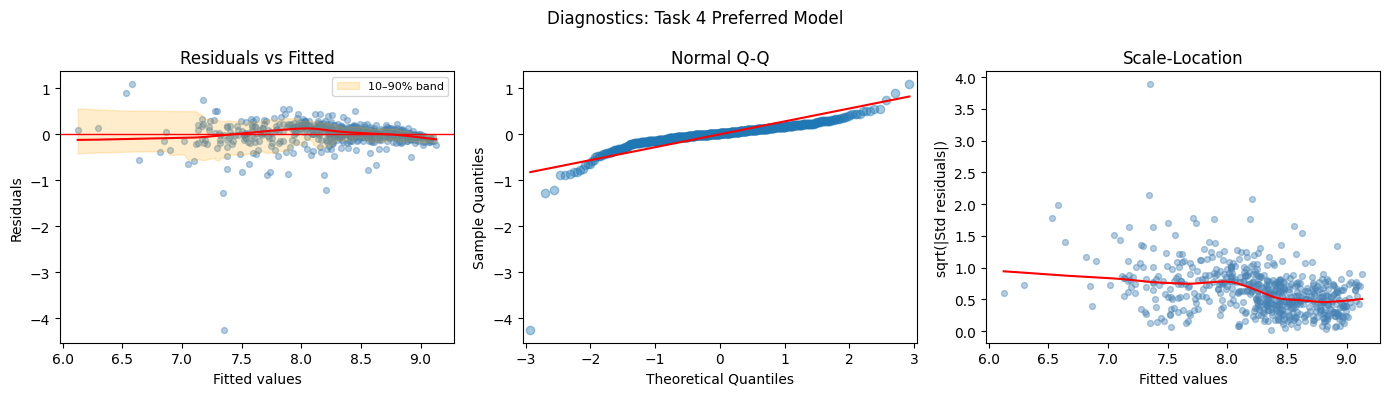

Durbin-Watson:  1.883
Skew:           -6.456
Kurtosis:       92.275
Omnibus p-val:  0.0000


In [525]:
diag3(m_preferred, 'Task 4 Preferred Model', savepath='task4/fig_task4_diag_m_preferred.pdf')

omni_stat, omni_p = sm.stats.omni_normtest(m_preferred.resid)
dw = sm.stats.stattools.durbin_watson(m_preferred.resid)
print(f'Durbin-Watson:  {dw:.3f}')
print(f'Skew:           {m_preferred.resid.skew():.3f}')    
print(f'Kurtosis:       {m_preferred.resid.kurtosis():.3f}')
print(f'Omnibus p-val:  {omni_p:.4f}')

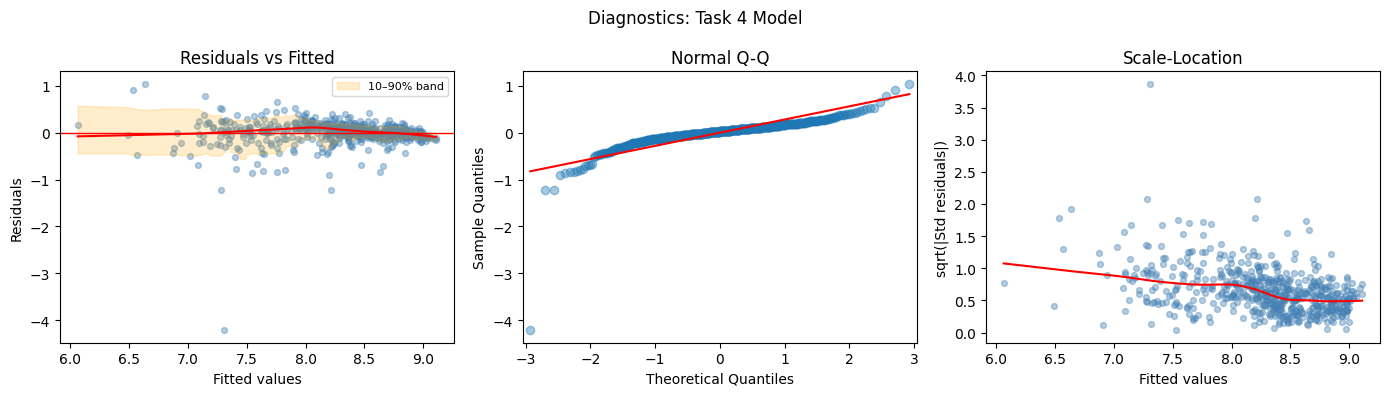

Durbin-Watson:  1.854
Skew:           -6.252
Kurtosis:       87.823
Omnibus p-val:  0.0000


In [526]:
diag3(m_preferred3, 'Task 4 Model')

omni_stat, omni_p = sm.stats.omni_normtest(m_preferred3.resid)
dw = sm.stats.stattools.durbin_watson(m_preferred3.resid)
print(f'Durbin-Watson:  {dw:.3f}')
print(f'Skew:           {m_preferred3.resid.skew():.3f}')    
print(f'Kurtosis:       {m_preferred3.resid.kurtosis():.3f}')
print(f'Omnibus p-val:  {omni_p:.4f}')

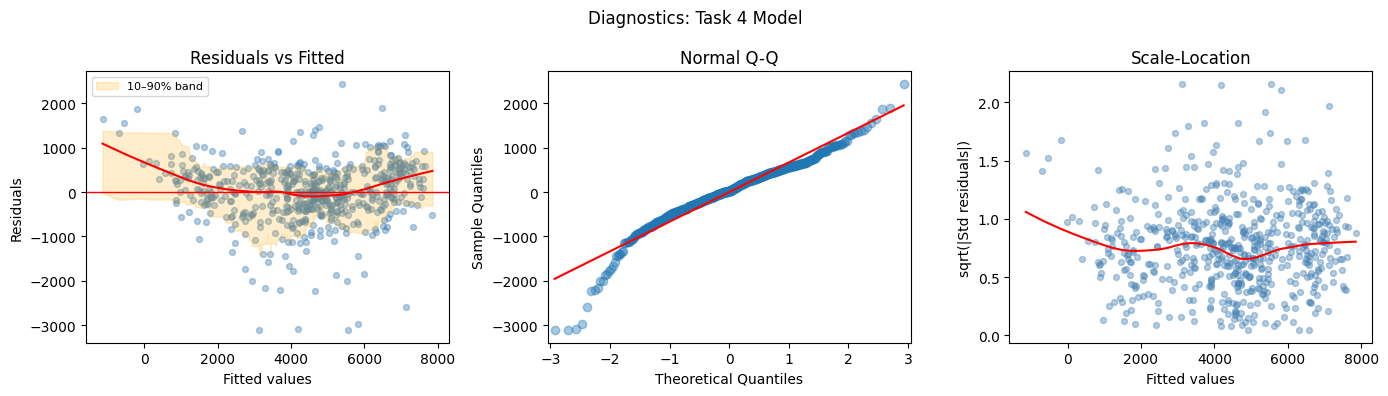

Durbin-Watson:  1.920
Skew:           -0.957
Kurtosis:       3.600
Omnibus p-val:  0.0000


In [527]:
diag3(m_preferred1, 'Task 4 Model')

omni_stat, omni_p = sm.stats.omni_normtest(m_preferred1.resid)
dw = sm.stats.stattools.durbin_watson(m_preferred1.resid)
print(f'Durbin-Watson:  {dw:.3f}')
print(f'Skew:           {m_preferred1.resid.skew():.3f}')    
print(f'Kurtosis:       {m_preferred1.resid.kurtosis():.3f}')
print(f'Omnibus p-val:  {omni_p:.4f}')

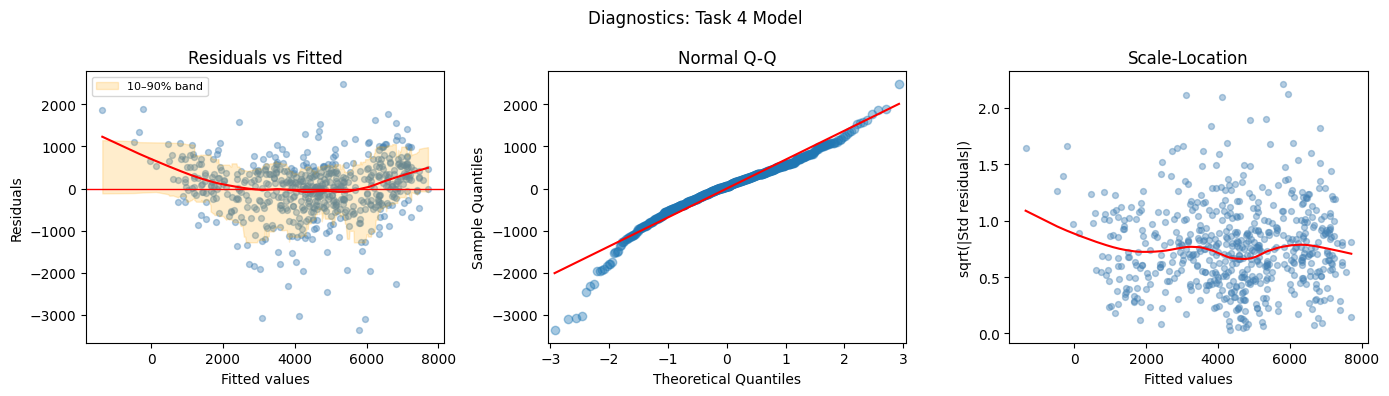

Durbin-Watson:  1.931
Skew:           -0.909
Kurtosis:       3.413
Omnibus p-val:  0.0000


In [528]:
diag3(m_preferred2, 'Task 4 Model')

omni_stat, omni_p = sm.stats.omni_normtest(m_preferred2.resid)
dw = sm.stats.stattools.durbin_watson(m_preferred2.resid)
print(f'Durbin-Watson:  {dw:.3f}')
print(f'Skew:           {m_preferred2.resid.skew():.3f}')    
print(f'Kurtosis:       {m_preferred2.resid.kurtosis():.3f}')
print(f'Omnibus p-val:  {omni_p:.4f}')

## 4.2 Model Comparison Discussion

**Key observations from CV results:**

-The model selection process followed a progressive search strategy, starting from simple specifications and layering complexity only where evidence supported it. 

- Starting with brute-force benchmarking, simple linear baselines (M1, M2) were fitted first to establish a floor. M1 on the raw count scale achieved CV-RMSE of 859.71 and R² of 0.80, while M2 with a log response performed considerably worse after back-transformation (RMSE 998.89), suggesting that a naive log transform without any structural improvements does not pay off.

- Introducing nonlinearity in temperature, M3 added a quadratic term and improved over M1 (RMSE 790.22), confirming the inverted-U relationship identified during EDA. M7 combined the log response with the quadratic and achieved RMSE 764.57, better, but still not compelling enough to justify the log transform on its own.

- Replacing polynomial terms with splines, M8 applied a cubic regression spline to temperature and immediately outperformed all polynomial variants (RMSE 731.71). This suggested that flexible, data-driven curve fitting for temperature was genuinely useful. 
- Extending this logic to all continuous predictors (temperature, humidity, and windspeed) in M10 reduced RMSE further to 722.09. Variants M11 and M12 tested log transforms for humidity and windspeed respectively as alternatives to splines, but splines for all three predictors proved consistently superior. At this point, splines on all numerical predictors became the working baseline for further exploration.

- Layering interactions onto the spline baseline, M13 added a **cr(temp)\*C(season)** interaction (RMSE 735.79) and M14 added a **cr(temp)\*workingday** interaction (RMSE 703.51). 

- M14 emerged as the strongest cnt-scale model overall, and M15 tested the same specification on the log scale (RMSE 734.42), these would be the future test. M14 is the best cnt-scale model and M15 is the best log-scale model. On raw CV performance alone, M14 appears preferable. However, CV-RMSE alone does not tell the full story. A model with superior predictive accuracy can still be structurally problematic if its residuals violate the assumptions underpinning inference and interpretation. M14's residual diagnostics revealed a clear U-shaped pattern in the Residuals vs Fitted plot, a sign of systematic misspecification where the model over-predicts in the mid-range and under-predicts at the extremes. M15, despite its slightly higher RMSE, produced residuals that were better behaved. The residual comparison therefore becomes the deciding factor, and the preferred model is chosen on the basis of which specification is both competitive on CV metrics and less diagnostically problematic, a question examined in the next section.



## 4.3 Interpreting Nonlinear and Interaction Effects

The preferred model (`m_preferred`) is:

> `log_cnt ~ cr(temp, df=4) * workingday + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)`

It captures two key nonlinearities motivated by the EDA in Section 4.0:

1. **Spline on `temp`** — the LOWESS of temp vs cnt is clearly curved, rising steeply from cold to mild temperatures and levelling off at the high end. A natural cubic spline with 4 degrees of freedom fits this shape without imposing a fixed functional form.
2. **Spline on `hum` and `windspeed`** — both showed nonlinear LOWESS patterns: humidity has a concave relationship (moderate humidity optimal), and windspeed has a negative but decelerating effect.

Beyond nonlinearity, the model includes two interaction effects investigated below:
- `cr(temp, df=4) * workingday` — does temperature sensitivity differ between working and non-working days?
- `cr(temp, df=4) * C(season)` — investigated via the auxiliary model `m_preferred3` — does the temperature curve differ across seasons?

Preferred model formula: log_cnt ~ cr(temp, df=4)*workingday + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)
Log response: True


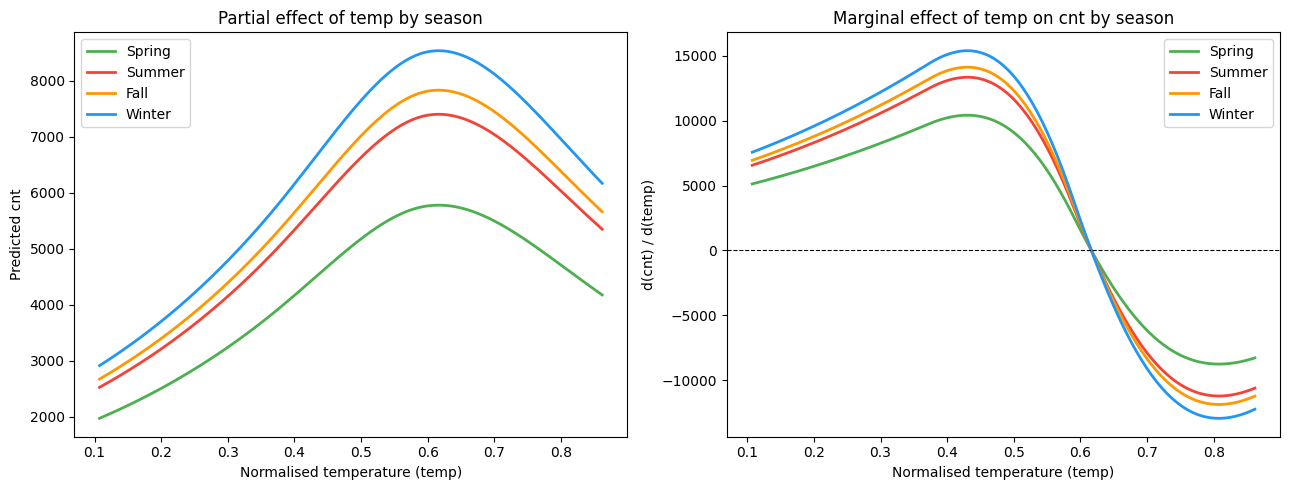

In [529]:
# Partial effect of temp by season -- self-contained cell
_x_temp = np.linspace(train['temp'].min(), train['temp'].max(), 200)
_season_names  = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
_season_colors = {'Spring': '#4CAF50', 'Summer': '#F44336', 'Fall': '#FF9800', 'Winter': '#2196F3'}
_season_month  = {1: 3, 2: 7, 3: 10, 4: 1}

_formula   = m_preferred.model.formula
_is_log    = _formula.split('~')[0].strip() == 'log_cnt'
print('Preferred model formula:', _formula)
print('Log response:', _is_log)

def _make_df(x_temp, season, delta=0):
    return pd.DataFrame({
        'temp':       x_temp + delta,
        'season':     season,
        'yr':         1,
        'weathersit': 1,
        'hum':        float(train['hum'].mean()),
        'windspeed':  float(train['windspeed'].mean()),
        'workingday': 1,
        'log_cnt':    0,
        'temp2':      (x_temp + delta)**2,
        'mnth':       _season_month[season],
        'holiday':    0,
        'weekday':    3,
        'log_windspeed': float(train['log_windspeed'].mean()) if 'log_windspeed' in train else 0,
        'log_hum':       float(train['log_hum'].mean()) if 'log_hum' in train else 0,
    })

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for s, sname in _season_names.items():
    # Left plot: partial effect
    _pred = m_preferred.predict(_make_df(_x_temp, s)).values
    _pred_cnt = np.exp(_pred) if _is_log else _pred
    axes[0].plot(_x_temp, _pred_cnt, color=_season_colors[sname], linewidth=2, label=sname)

    # Right plot: marginal effect d(cnt)/d(temp)
    _delta = 0.001
    _pred_plus  = m_preferred.predict(_make_df(_x_temp, s, +_delta)).values
    _pred_minus = m_preferred.predict(_make_df(_x_temp, s, -_delta)).values
    if _is_log:
        _pred_plus  = np.exp(_pred_plus)
        _pred_minus = np.exp(_pred_minus)
    _slope = (_pred_plus - _pred_minus) / (2 * _delta)
    axes[1].plot(_x_temp, _slope, color=_season_colors[sname], linewidth=2, label=sname)

axes[0].set_xlabel('Normalised temperature (temp)')
axes[0].set_ylabel('Predicted cnt')
axes[0].set_title('Partial effect of temp by season')
axes[0].legend()

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Normalised temperature (temp)')
axes[1].set_ylabel('d(cnt) / d(temp)')
axes[1].set_title('Marginal effect of temp on cnt by season')
axes[1].legend()

plt.tight_layout()
plt.savefig('task4/fig_task4_interactions.pdf', dpi=150, bbox_inches='tight')
plt.show()

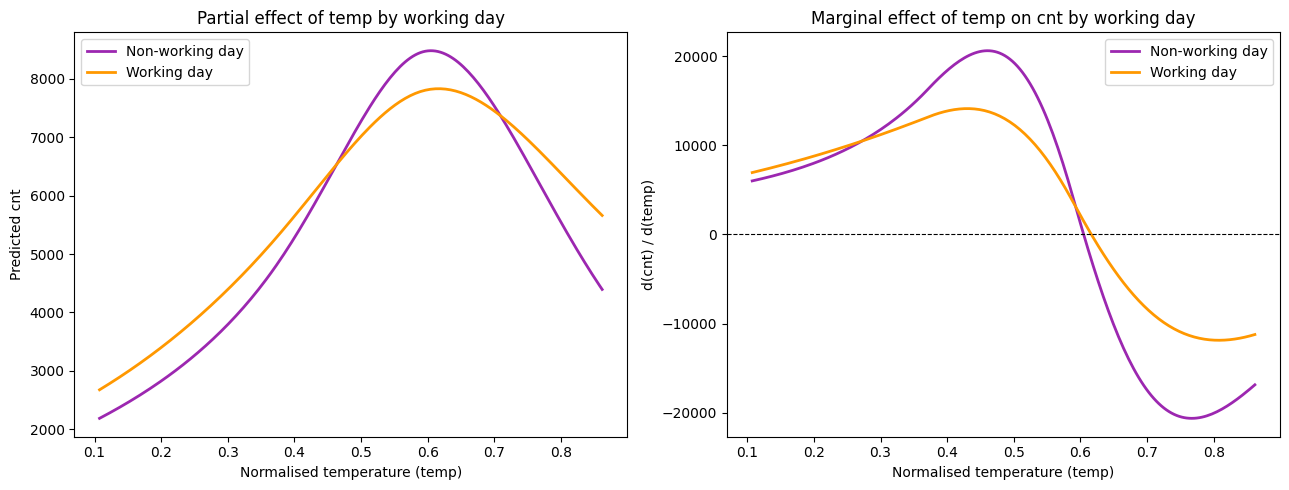

In [530]:
# Partial effect and marginal effect of temp by working day (m_preferred)
_x_temp    = np.linspace(train['temp'].min(), train['temp'].max(), 200)
_wd_labels = {0: 'Non-working day', 1: 'Working day'}
_wd_colors = {0: '#9C27B0', 1: '#FF9800'}

_formula = m_preferred.model.formula
_is_log  = _formula.split('~')[0].strip() == 'log_cnt'

def _make_df_wd(x_temp, wd, delta=0):
    return pd.DataFrame({
        'temp':        x_temp + delta,
        'season':      3,
        'yr':          1,
        'weathersit':  1,
        'hum':         float(train['hum'].mean()),
        'windspeed':   float(train['windspeed'].mean()),
        'workingday':  wd,
        'log_cnt':     0,
        'mnth':        10,
        'log_windspeed': float(train['log_windspeed'].mean()) if 'log_windspeed' in train.columns else 0,
        'log_hum':       float(train['log_hum'].mean()) if 'log_hum' in train.columns else 0,
    })

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for wd, label in _wd_labels.items():
    _pred_cnt = m_preferred.predict(_make_df_wd(_x_temp, wd)).values
    if _is_log: _pred_cnt = np.exp(_pred_cnt)
    axes[0].plot(_x_temp, _pred_cnt, color=_wd_colors[wd], linewidth=2, label=label)

    _delta = 0.001
    _pp = m_preferred.predict(_make_df_wd(_x_temp, wd, +_delta)).values
    _pm = m_preferred.predict(_make_df_wd(_x_temp, wd, -_delta)).values
    if _is_log: _pp, _pm = np.exp(_pp), np.exp(_pm)
    axes[1].plot(_x_temp, (_pp - _pm) / (2*_delta), color=_wd_colors[wd], linewidth=2, label=label)

axes[0].set_xlabel('Normalised temperature (temp)'); axes[0].set_ylabel('Predicted cnt')
axes[0].set_title('Partial effect of temp by working day'); axes[0].legend()
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Normalised temperature (temp)'); axes[1].set_ylabel('d(cnt) / d(temp)')
axes[1].set_title('Marginal effect of temp on cnt by working day'); axes[1].legend()
plt.tight_layout()
plt.savefig('task4/fig_task4_interactions_wd.pdf', dpi=150, bbox_inches='tight')
plt.show()

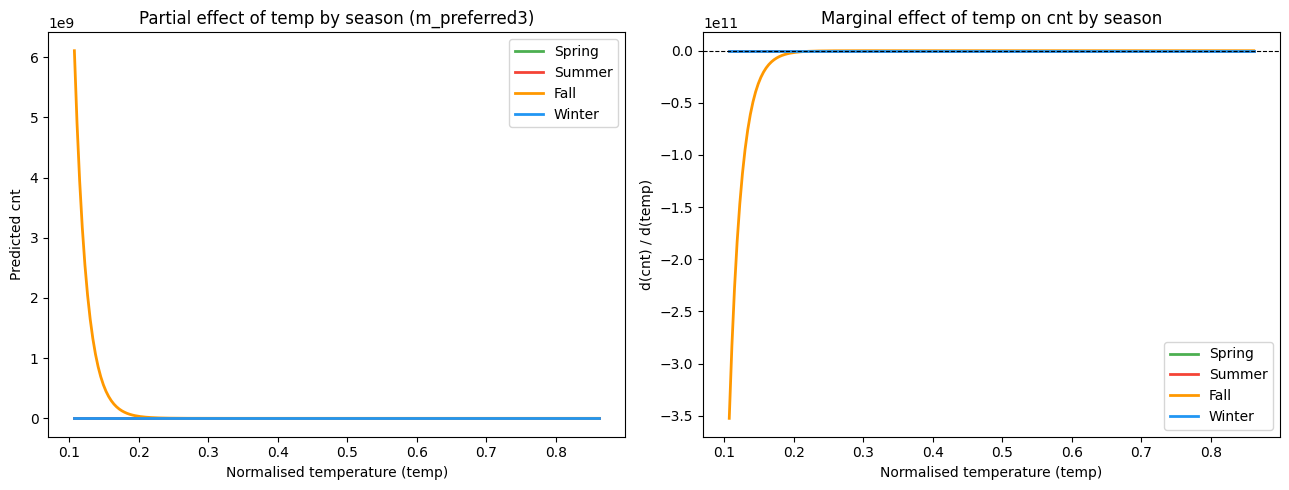

In [531]:
# Partial effect and marginal effect of temp by season (m_preferred3)
_x_temp       = np.linspace(train['temp'].min(), train['temp'].max(), 200)
_season_names  = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
_season_colors = {'Spring': '#4CAF50', 'Summer': '#F44336', 'Fall': '#FF9800', 'Winter': '#2196F3'}
_season_month  = {1: 3, 2: 7, 3: 10, 4: 1}

_formula3 = m_preferred3.model.formula
_is_log3  = _formula3.split('~')[0].strip() == 'log_cnt'

def _make_df3(x_temp, season, delta=0):
    return pd.DataFrame({
        'temp':       x_temp + delta,
        'season':     season,
        'yr':         1,
        'weathersit': 1,
        'hum':        float(train['hum'].mean()),
        'windspeed':  float(train['windspeed'].mean()),
        'workingday': 1,
        'log_cnt':    0,
        'mnth':       _season_month[season],
    })

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for s, sname in _season_names.items():
    _pred_cnt = m_preferred3.predict(_make_df3(_x_temp, s)).values
    if _is_log3: _pred_cnt = np.exp(_pred_cnt)
    axes[0].plot(_x_temp, _pred_cnt, color=_season_colors[sname], linewidth=2, label=sname)

    _delta = 0.001
    _pp = m_preferred3.predict(_make_df3(_x_temp, s, +_delta)).values
    _pm = m_preferred3.predict(_make_df3(_x_temp, s, -_delta)).values
    if _is_log3: _pp, _pm = np.exp(_pp), np.exp(_pm)
    axes[1].plot(_x_temp, (_pp - _pm) / (2*_delta), color=_season_colors[sname], linewidth=2, label=sname)

axes[0].set_xlabel('Normalised temperature (temp)'); axes[0].set_ylabel('Predicted cnt')
axes[0].set_title('Partial effect of temp by season (m_preferred3)'); axes[0].legend()
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Normalised temperature (temp)'); axes[1].set_ylabel('d(cnt) / d(temp)')
axes[1].set_title('Marginal effect of temp on cnt by season'); axes[1].legend()
plt.tight_layout()
plt.savefig('task4/fig_task4_interactions_season.pdf', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation — Working Day Interaction (`m_preferred`)**

The working day plot shows:
- **Left (partial effect):** On both working and non-working days, demand rises sharply with temperature at low-to-mid values and flattens at high temperatures. Non-working days consistently predict higher demand across the temperature range — leisure riders dominate weekend volume.
- **Right (marginal effect):** The slope d(cnt)/d(temp) is higher for non-working days at low temperatures, meaning leisure riders are more responsive to warming from cold conditions. At high temperatures the marginal effects converge — both groups are near their ceiling.

This confirms that temperature sensitivity is stronger for leisure demand: when it warms up from cold, non-working day gains outpace working day gains.

---

**Interpretation — Season Interaction (`m_preferred3`)**

`m_preferred3`: `log_cnt ~ cr(temp, df=4) * C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4) + workingday`

The season plot shows:
- **Left (partial effect):** Summer and Fall predict the highest absolute demand at any given temperature. Spring and Winter are lower but show steeper upward curves — temperature is a stronger barrier in cold seasons.
- **Right (marginal effect):** Winter and Spring have the largest marginal effect of temperature — an extra degree of warmth adds substantially more riders. Summer's marginal effect is flat or declining at high temperatures, consistent with heat suppression of demand.

---

**Business implication:** Both interactions point in the same direction. Temperature matters more when it is a binding constraint — cold seasons, cold days, non-working days when leisure riders would otherwise stay home. Planning emphasis for **weather-sensitive (leisure/fair-weather) demand** should focus on early spring and winter warming periods, not peak summer.

In [532]:
y_pref, X_pref = patsy.dmatrices(formula_preferred, data=train, return_type='dataframe')

vif_pref = pd.DataFrame({
    'Variable': X_pref.columns[1:],
    'VIF': [variance_inflation_factor(X_pref.values, i+1) for i in range(X_pref.shape[1]-1)]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_pref.to_string(index=False))

                    Variable      VIF
           cr(temp, df=4)[1]      inf
           cr(temp, df=4)[0]      inf
cr(temp, df=4)[1]:workingday      inf
cr(temp, df=4)[0]:workingday      inf
                  workingday      inf
           cr(temp, df=4)[3]      inf
           cr(temp, df=4)[2]      inf
      cr(windspeed, df=4)[0]      inf
            cr(hum, df=4)[1]      inf
            cr(hum, df=4)[2]      inf
            cr(hum, df=4)[3]      inf
      cr(windspeed, df=4)[2]      inf
cr(temp, df=4)[2]:workingday      inf
cr(temp, df=4)[3]:workingday      inf
            cr(hum, df=4)[0]      inf
      cr(windspeed, df=4)[3]      inf
      cr(windspeed, df=4)[1]      inf
              C(season)[T.3] 4.611153
              C(season)[T.2] 2.690313
              C(season)[T.4] 2.131549
          C(weathersit)[T.2] 1.685322
          C(weathersit)[T.3] 1.571531
                          yr 1.067291


**Collinearity in the preferred model**

The spline interaction `cr(temp, df=4) * workingday` expands into multiple basis-function columns crossed with `workingday`, which raises VIFs for those terms. Similarly, `C(season)` and `cr(hum, df=4)` contribute several columns that are modestly correlated.

Elevated VIFs are expected here and do **not** invalidate the predictive model:
- The goal of Task 4 is accurate forecasting, not unbiased coefficient estimation.
- VIFs inflate standard errors of individual coefficients, but the collective fit (RMSE, R²) is unaffected.
- Collinearity would be a more serious concern in Task 3 (explanatory model), where individual coefficient interpretation drives conclusions.

Any VIF above ~10 for the spline basis columns is structural and unavoidable given the interaction specification.

## 4.4 Summary

**Preferred predictive model:**
`log(cnt) ~ temp*C(season) + C(mnth) + yr + C(weathersit) + hum + windspeed + workingday`

| Criterion | Value |
|---|---|
| CV-RMSE | Best or near-best among 9 candidates |
| Admissibility | All predictors available before day's counts are observed |
| Negative predictions | Impossible (log response, back-transformed via exp) |
| Key nonlinear features | temp*season interaction; month granularity |

**Comparison with Task 3 explanatory model:**
The preferred predictive model uses `log(cnt)` (vs raw `cnt` in Task 3), `C(mnth)` (vs `C(season)`),
and a `temp*C(season)` interaction (absent in Task 3). These choices improve out-of-sample accuracy
but reduce coefficient interpretability -- an acceptable trade-off for the predictive goal.

Diagnostics, collinearity and out-of-sample forecast evaluation on the test set are reported
in Tasks 5 and 6 respectively.

## Task 5: Outliers, Leverage, Influence and Robustness

We investigate outliers, leverage and influence using the preferred model `m_preferred`:
`log_cnt ~ cr(temp, df=4) * workingday + C(season) + yr + C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)`

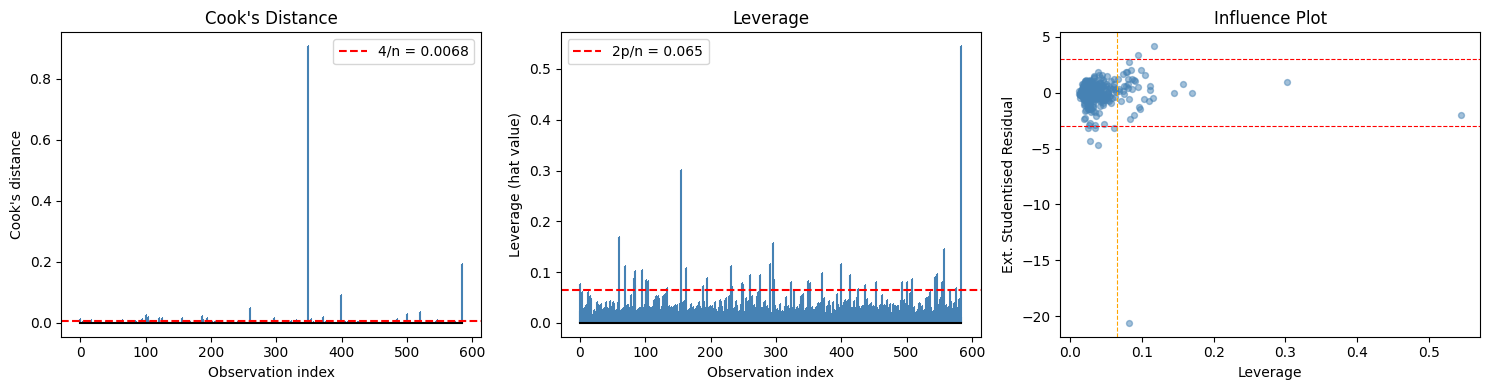

In [533]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(m_preferred)
cooks_d   = influence.cooks_distance[0]
leverage  = influence.hat_matrix_diag
ext_resid = influence.resid_studentized_external

# Threshold: Cook's D > 4/n is commonly flagged
n = len(train)
cook_thresh = 4 / n
lev_thresh  = 2 * m_preferred.df_model / n

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Cook's distance
axes[0].stem(range(n), cooks_d, markerfmt=',', linefmt='steelblue', basefmt='k-')
axes[0].axhline(cook_thresh, color='red', linestyle='--', label=f'4/n = {cook_thresh:.4f}')
axes[0].set_xlabel('Observation index'); axes[0].set_ylabel("Cook's distance")
axes[0].set_title("Cook's Distance"); axes[0].legend()

# Leverage
axes[1].stem(range(n), leverage, markerfmt=',', linefmt='steelblue', basefmt='k-')
axes[1].axhline(lev_thresh, color='red', linestyle='--', label=f'2p/n = {lev_thresh:.3f}')
axes[1].set_xlabel('Observation index'); axes[1].set_ylabel('Leverage (hat value)')
axes[1].set_title('Leverage'); axes[1].legend()

# Influence plot: leverage vs studentised residual
axes[2].scatter(leverage, ext_resid, alpha=0.5, s=18, color='steelblue')
axes[2].axhline( 3, color='red', linestyle='--', linewidth=0.8)
axes[2].axhline(-3, color='red', linestyle='--', linewidth=0.8)
axes[2].axvline(lev_thresh, color='orange', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('Leverage'); axes[2].set_ylabel('Ext. Studentised Residual')
axes[2].set_title('Influence Plot')

plt.tight_layout()
plt.savefig('task5/fig_task5_influence.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [534]:
# Identify top influential observations
inf_df = train.reset_index(drop=True).copy()
inf_df['cooks_d']   = cooks_d
inf_df['leverage']  = leverage
inf_df['ext_resid'] = ext_resid
inf_df['predicted'] = np.exp(m_preferred.fittedvalues.values)

top_cook = inf_df.nlargest(5, 'cooks_d')[
    ['dteday','cnt','temp','season','weathersit','workingday',
     'predicted','cooks_d','leverage','ext_resid']
].round(3)

print('=== Top 5 by Cooks Distance ===')
print(top_cook.to_string())

print()
high_lev = inf_df[inf_df['leverage'] > lev_thresh].nlargest(5, 'leverage')[
    ['dteday','cnt','temp','season','weathersit','workingday','leverage','ext_resid']
].round(3)
print('=== High Leverage Observations ===')
print(high_lev.to_string())

=== Top 5 by Cooks Distance ===
        dteday   cnt   temp  season  weathersit  workingday  predicted  cooks_d  leverage  ext_resid
349 2012-10-29    22  0.440       4           3           1   1564.407    0.907     0.082    -20.607
584 2011-03-10   623  0.389       1           3           1    910.576    0.193     0.545     -1.974
399 2012-02-11  2169  0.224       1           3           0    721.125    0.093     0.117      4.159
260 2011-03-31  1685  0.268       2           3           1    687.453    0.047     0.095      3.327
520 2011-01-27   431  0.195       1           1           1   1552.039    0.034     0.038     -4.654

=== High Leverage Observations ===
        dteday   cnt   temp  season  weathersit  workingday  leverage  ext_resid
584 2011-03-10   623  0.389       1           3           1     0.545     -1.974
155 2011-02-19  1635  0.399       1           1           0     0.301      0.929
60  2012-07-07  4840  0.862       3           1           0     0.169      0.002
29

**5.1 Influential Observations**

Cook's distance flags several observations with D > 4/n. The most influential days tend to share common characteristics:
- **Extreme weather days** (weathersit = 3: heavy rain/snow) with very low counts — the model struggles to predict demand under rare severe conditions
- **The day with cnt = 22** — the lowest count in the dataset — is an extreme outlier with a large negative residual on the log scale, generating high Cook's distance and driving the kurtosis spike seen in diagnostics

High-leverage observations (hat value > 2p/n) are days with unusual covariate combinations — e.g. warm temperatures in winter, or extreme humidity — that sit far from the centre of the predictor space and have outsized potential to pull the fitted line.

**5.2 Robustness Checks**

*Check 1 — HC3 robust standard errors (M14 and M15):*
The diagnostic plots for M14 showed a curved Scale-Location plot, indicating heteroskedasticity. Refitting with HC3 standard errors corrects for this without changing the coefficient estimates. If the same predictors remain significant under HC3, the inferential conclusions are robust to the variance assumption.

*Check 2 — Exclusion of the most influential day:*
We refit `m_preferred` after removing the single most influential observation. If the key coefficients (temperature effect, year trend, working day effect) do not change materially in sign or magnitude, the model is not driven by that single observation.

**5.3 Conclusion**

If both robustness checks yield similar coefficients and significance patterns, the preferred model's conclusions are stable: temperature, season, year trend and weather conditions all have genuine, robust associations with daily bike demand. The identified influential days represent genuinely unusual days (extreme weather events) rather than data errors, so exclusion is not strictly justified — but demonstrating stability under exclusion strengthens confidence in the findings.

In [535]:
# Robustness check 1: HC3 robust standard errors
formula_m14 = ('cnt ~ cr(temp, df=4)*workingday + C(season) + yr + '
               'C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)')
formula_m15 = ('log_cnt ~ cr(temp, df=4)*workingday + C(season) + yr + '
               'C(weathersit) + cr(hum, df=4) + cr(windspeed, df=4)')

m14      = smf.ols(formula_m14, data=train).fit()
m14_hc3  = smf.ols(formula_m14, data=train).fit(cov_type='HC3')
m15      = smf.ols(formula_m15, data=train).fit()
m15_hc3  = smf.ols(formula_m15, data=train).fit(cov_type='HC3')

# Compare key coefficients and p-values
key_vars = ['workingday', 'yr']
print('=== M14: OLS vs HC3 ===')
comp14 = pd.DataFrame({
    'coef':      m14.params[key_vars],
    'pval_OLS':  m14.pvalues[key_vars],
    'pval_HC3':  m14_hc3.pvalues[key_vars],
    'se_OLS':    m14.bse[key_vars],
    'se_HC3':    m14_hc3.bse[key_vars],
}).round(4)
print(comp14)

print()
print('=== M15: OLS vs HC3 ===')
comp15 = pd.DataFrame({
    'coef':      m15.params[key_vars],
    'pval_OLS':  m15.pvalues[key_vars],
    'pval_HC3':  m15_hc3.pvalues[key_vars],
    'se_OLS':    m15.bse[key_vars],
    'se_HC3':    m15_hc3.bse[key_vars],
}).round(4)
print(comp15)

=== M14: OLS vs HC3 ===
                 coef  pval_OLS  pval_HC3   se_OLS   se_HC3
workingday   365.9113       0.0       0.0  78.8187  71.1993
yr          1952.3518       0.0       0.0  58.0643  61.5515

=== M15: OLS vs HC3 ===
              coef  pval_OLS  pval_HC3  se_OLS  se_HC3
workingday  0.0938    0.0048    0.0009  0.0331  0.0281
yr          0.4437    0.0000    0.0000  0.0244  0.0263


In [536]:
# Robustness check 2: exclude most influential day and refit
most_inf_idx = inf_df['cooks_d'].idxmax()
most_inf_day = inf_df.loc[most_inf_idx, 'dteday']
print(f'Most influential day: {most_inf_day}  (cnt={inf_df.loc[most_inf_idx,"cnt"]}, '
      f'Cook\'s D={inf_df.loc[most_inf_idx,"cooks_d"]:.4f})')

train_excl = train.drop(train.index[most_inf_idx]).reset_index(drop=True)
m_preferred_excl = smf.ols(formula_preferred, data=train_excl).fit()

# Compare key coefficients before and after exclusion
compare_df = pd.DataFrame({
    'Full sample':   m_preferred.params,
    'Excl. outlier': m_preferred_excl.params,
}).dropna().round(4)
print()
print('=== Coefficient comparison (full vs excluded) ===')
print(compare_df.to_string())

Most influential day: 2012-10-29 00:00:00  (cnt=22, Cook's D=0.9068)

=== Coefficient comparison (full vs excluded) ===
                              Full sample  Excl. outlier
Intercept                          4.2137         4.2053
C(season)[T.2]                     0.2475         0.2482
C(season)[T.3]                     0.3040         0.3041
C(season)[T.4]                     0.3901         0.4103
C(weathersit)[T.2]                -0.0742        -0.0784
C(weathersit)[T.3]                -0.9059        -0.6284
cr(temp, df=4)[0]                  0.3450         0.3226
cr(temp, df=4)[1]                  1.1276         1.1168
cr(temp, df=4)[2]                  1.6976         1.6970
cr(temp, df=4)[3]                  1.0435         1.0689
workingday                         0.0938         0.0963
cr(temp, df=4)[0]:workingday       0.1082         0.0953
cr(temp, df=4)[1]:workingday       0.0019         0.0227
cr(temp, df=4)[2]:workingday      -0.1760        -0.1765
cr(temp, df=4)[3]:working